# Bottleneck VAE Training - 256 Latent Dimensions
Training BottleneckVAE with BottleneckEncoder and ComplexBottleneckDeconvDecoder using VAE loss with KL divergence

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from tqdm.auto import tqdm
import nibabel as nib

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.vae.vae_bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckVAE,
)
from models.vae.model import VAELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Define VAE Loss Function

In [2]:
class WeightedVAELoss(nn.Module):
    """
    Combines weighted reconstruction loss with a STANDARD (Monotonic) Beta Warmup.
    Removes the 'cyclical' instability.
    """
    def __init__(self, weight_mask_path, target_shape=None, beta_final=0.0005, warmup_steps=5000):
        super().__init__()
        
        # --- 1. Load and Setup Weight Mask (Keep this, it is good) ---
        weight_nii = nib.load(weight_mask_path)
        weight_data = weight_nii.get_fdata()
        weight_tensor = torch.from_numpy(weight_data).float()
        
        # Resize mask to match model output
        if target_shape is not None:
            weight_tensor = weight_tensor.unsqueeze(0).unsqueeze(0) 
            weight_tensor = F.interpolate(
                weight_tensor, 
                size=target_shape, 
                mode='trilinear', 
                align_corners=False
            )
            weight_tensor = weight_tensor.squeeze(0).squeeze(0)
        
        # Normalize weights so they don't change the scale of the loss too much
        self.register_buffer('weight_mask', weight_tensor.unsqueeze(0).unsqueeze(0) / weight_tensor.mean())
        
        # --- 2. Setup Standard Warmup (Fixing the oscillation) ---
        self.beta_final = beta_final
        self.warmup_steps = warmup_steps
        self.current_step = 0
    
    def forward(self, recon_x, x, mu, log_var):
        # Ensure mask is on correct device
        if self.weight_mask.device != recon_x.device:
            self.weight_mask = self.weight_mask.to(recon_x.device)
            
        # --- Reconstruction Loss (Weighted) ---
        # We apply the mask here to focus on the brain
        squared_error = (recon_x - x) ** 2
        weighted_error = squared_error * self.weight_mask
        recon_loss = weighted_error.mean()
        
        # --- KL Divergence ---
        # Standard calculation
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
        kl_loss = torch.mean(kl_loss)
        
        # --- Beta Calculation (Monotonic, NOT Cyclical) ---
        # Linearly increase beta from 0 to beta_final over 'warmup_steps'
        if self.current_step < self.warmup_steps:
            beta = self.beta_final * (self.current_step / self.warmup_steps)
        else:
            beta = self.beta_final # Stay constant after warmup!
            
        self.current_step += 1
        
        # Total Loss
        total_loss = recon_loss + (beta * kl_loss)
        
        return total_loss, recon_loss, kl_loss, beta

In [3]:
# Create weighted VAE loss criterion
criterion = WeightedVAELoss("data/masks/weightMatrix.nii", target_shape=(64, 128, 128))
print("Weighted VAE loss criterion created")

Weighted VAE loss criterion created


## Data Setup

In [4]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BottleneckVAETraining"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [5]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [6]:
target_shape = (64, 128, 128)
latent_dim = 256

def build_vae_model(latent_dim=256):
    """Build BottleneckVAE model"""
    model = BottleneckVAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        latent_dim=latent_dim
    )
    return model.to(device)

model = build_vae_model(latent_dim=latent_dim)
num_params = count_trainable(model)
print(f"Model Parameters: {num_params / 1e6:.2f}M")

Model Parameters: 24.69M


## Training Loop

In [7]:
def train_vae_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, batch in enumerate(pbar):
        data = batch['volume'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon, mu, log_var = model(data)
        
        # Compute loss
        loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.6f}',
            'recon': f'{recon_loss.item():.6f}',
            'kl': f'{kl_loss.item():.6f}',
            'beta': f'{beta:.6f}'
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_kl = total_kl / len(train_loader)
    
    return avg_loss, avg_recon, avg_kl

def validate_vae(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation", leave=False)
        for batch in pbar:
            data = batch['volume'].to(device)
            
            # Forward pass
            recon, mu, log_var = model(data)
            
            # Compute loss
            loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.6f}',
                'recon': f'{recon_loss.item():.6f}',
                'kl': f'{kl_loss.item():.6f}'
            })
    
    avg_loss = total_loss / len(val_loader)
    avg_recon = total_recon / len(val_loader)
    avg_kl = total_kl / len(val_loader)
    
    return avg_loss, avg_recon, avg_kl

In [8]:
# Training configuration
num_epochs = 150
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

# Training history
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []
val_recon_losses = []
val_kl_losses = []

best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 20

model_name = f"bottleneck_vae_lat{latent_dim}"
checkpoint_dir = os.path.join(output_dir, model_name)
os.makedirs(checkpoint_dir, exist_ok=True)

if __name__ == '__main__':
    print(f"Starting training for {num_epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        
        # Train
        train_loss, train_recon, train_kl = train_vae_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_recon_losses.append(train_recon)
        train_kl_losses.append(train_kl)
        
        # Validate
        val_loss, val_recon, val_kl = validate_vae(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_recon_losses.append(val_recon)
        val_kl_losses.append(val_kl)
        
        print(f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.6f})")
        print(f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.6f})")
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping and checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ Best model saved: {best_model_path}")
        else:
            patience_counter += 1
        
        # Save periodic checkpoint
        if (epoch + 1) % 10 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_path}")
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.1f}s")
    print(f"Best validation loss: {best_val_loss:.6f}")

Starting training for 150 epochs...

Epoch [1/150]


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/595 [00:00<?, ?it/s]

Validation:   0%|          | 0/149 [00:00<?, ?it/s]

Train Loss: 0.051424 (Recon: 0.047669, KL: 315.324637)
Val Loss: 0.027669 (Recon: 0.023489, KL: 62.458213)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [2/150]


...

Validation:   0%|          | 0/149 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fadecc03d80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7fadecc03d80>^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
^    ^if w.is_alive():^
^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'  
  ^ ^ ^  ^ ^ ^ ^ ^ ^ ^^^^^^
^  File "

Train Loss: 0.020018 (Recon: 0.016408, KL: 7.221166)
Val Loss: 0.017893 (Recon: 0.014252, KL: 7.281276)

Epoch [110/150]


Training:   0%|          | 0/595 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fadecc03d80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fadecc03d80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 15

## Results Summary

In [9]:
# Create results dataframe
results_df = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Train Loss': train_losses,
    'Val Loss': val_losses,
    'Train Recon': train_recon_losses,
    'Train KL': train_kl_losses,
    'Val Recon': val_recon_losses,
    'Val KL': val_kl_losses,
})

# Save results
results_path = os.path.join(checkpoint_dir, f"{model_name}_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

print(results_df.tail(30))

Results saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_results.csv
     Epoch  Train Loss  Val Loss  Train Recon  Train KL  Val Recon    Val KL
104    105    0.020027  0.017874     0.016423  7.207070   0.014308  7.131050
105    106    0.019971  0.017969     0.016432  7.078635   0.014319  7.300877
106    107    0.019952  0.018053     0.016248  7.409115   0.014573  6.959997
107    108    0.020127  0.018134     0.016430  7.393192   0.014457  7.354587
108    109    0.020018  0.017893     0.016408  7.221166   0.014252  7.281276
109    110    0.019837  0.017693     0.016290  7.094090   0.014226  6.934893
110    111    0.019868  0.017722     0.016274  7.187969   0.014213  7.017814
111    112    0.020008  0.018035     0.016311  7.394480   0.014242  7.585609
112    113    0.019859  0.017668     0.016239  7.239724   0.014202  6.932568
113    114    0.019767  0.017649     0.016231  7.071084   0.014170  6.958130
114    115    0.019853  0.017915     0

## Visualization

Plot saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_training_curves.png


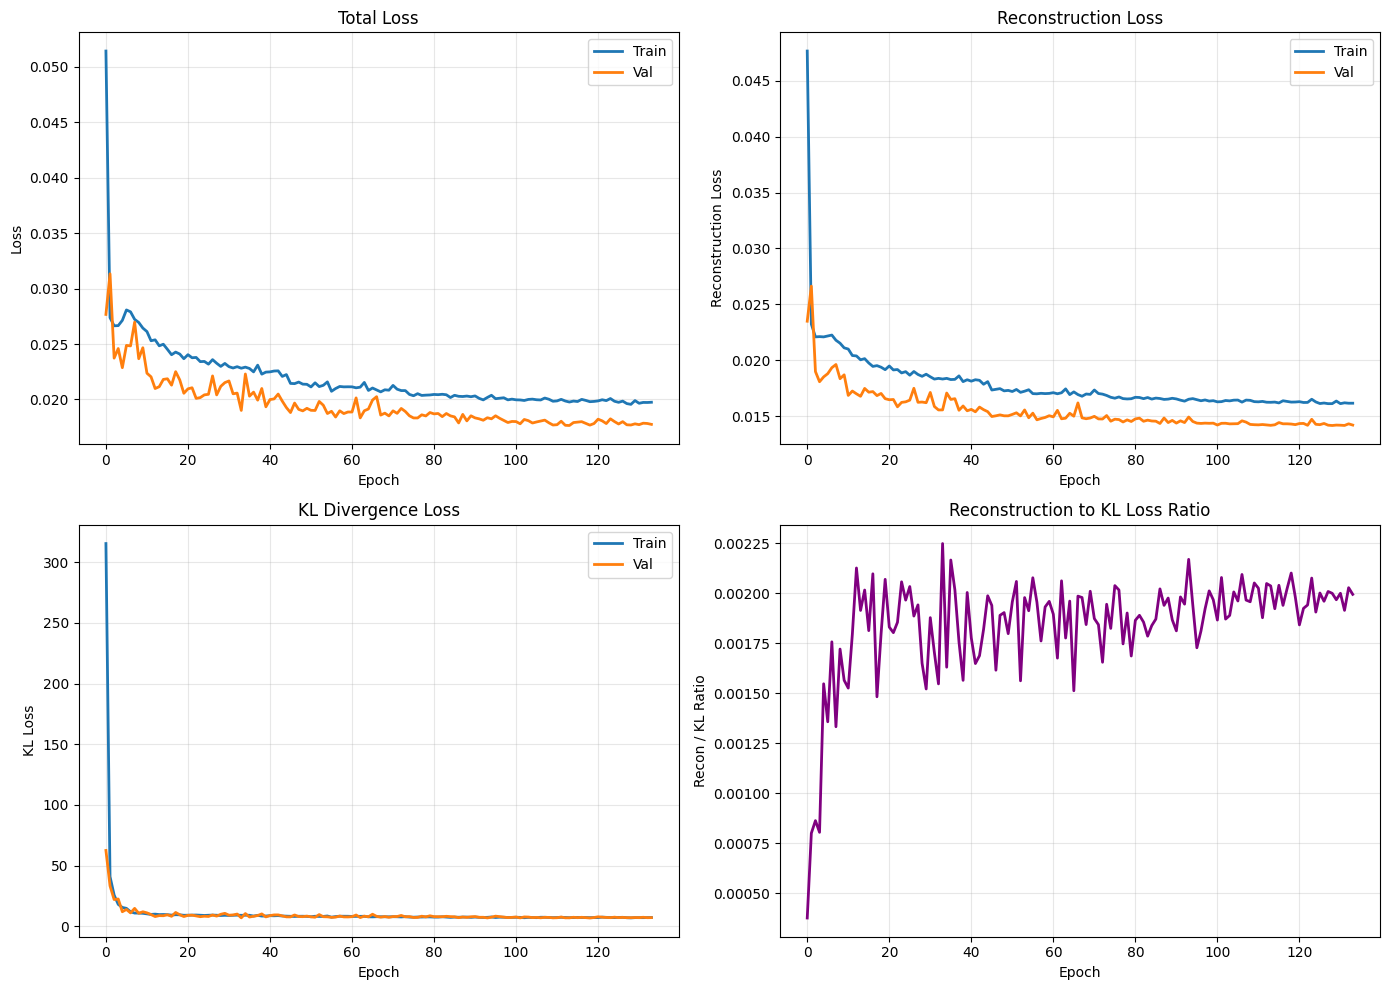

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(train_losses, label='Train', linewidth=2)
axes[0, 0].plot(val_losses, label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(train_recon_losses, label='Train', linewidth=2)
axes[0, 1].plot(val_recon_losses, label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KL loss
axes[1, 0].plot(train_kl_losses, label='Train', linewidth=2)
axes[1, 0].plot(val_kl_losses, label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Loss')
axes[1, 0].set_title('KL Divergence Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss ratio
recon_kl_ratio = [r / (k + 1e-8) for r, k in zip(val_recon_losses, val_kl_losses)]
axes[1, 1].plot(recon_kl_ratio, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recon / KL Ratio')
axes[1, 1].set_title('Reconstruction to KL Loss Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(checkpoint_dir, f"{model_name}_training_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

In [12]:
# Load best model
best_model = build_vae_model(latent_dim=latent_dim)
best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
best_model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best model from: {best_model_path}")

# Test on a few samples
best_model.eval()
with torch.no_grad():
    # 1. Get the dictionary batch
    batch = next(iter(val_loader))
    
    # 2. Extract the actual image tensor using the 'volume' key
    # (The error logs show 'volume' is one of the keys)
    test_data = batch['volume']
    
    # 3. Now you can move it to device
    test_data = test_data.to(device)
    
    # Forward pass
    recon, mu, log_var = best_model(test_data)
    
    # Compute loss
    loss, recon_loss, kl_loss, beta = criterion(recon, test_data, mu, log_var)
    
    print(f"\nTest Batch Results:")
    print(f"Total Loss: {loss.item():.6f}")
    print(f"Reconstruction Loss: {recon_loss.item():.6f}")
    print(f"KL Loss: {kl_loss.item():.6f}")
    print(f"Beta: {beta:.6f}")
    print(f"Latent Mean: {mu.mean().item():.6f}")
    print(f"Latent Std: {mu.std().item():.6f}")

Loaded best model from: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Test Batch Results:
Total Loss: 0.018894
Reconstruction Loss: 0.015920
KL Loss: 5.948587
Beta: 0.000500
Latent Mean: 0.009031
Latent Std: 0.193122


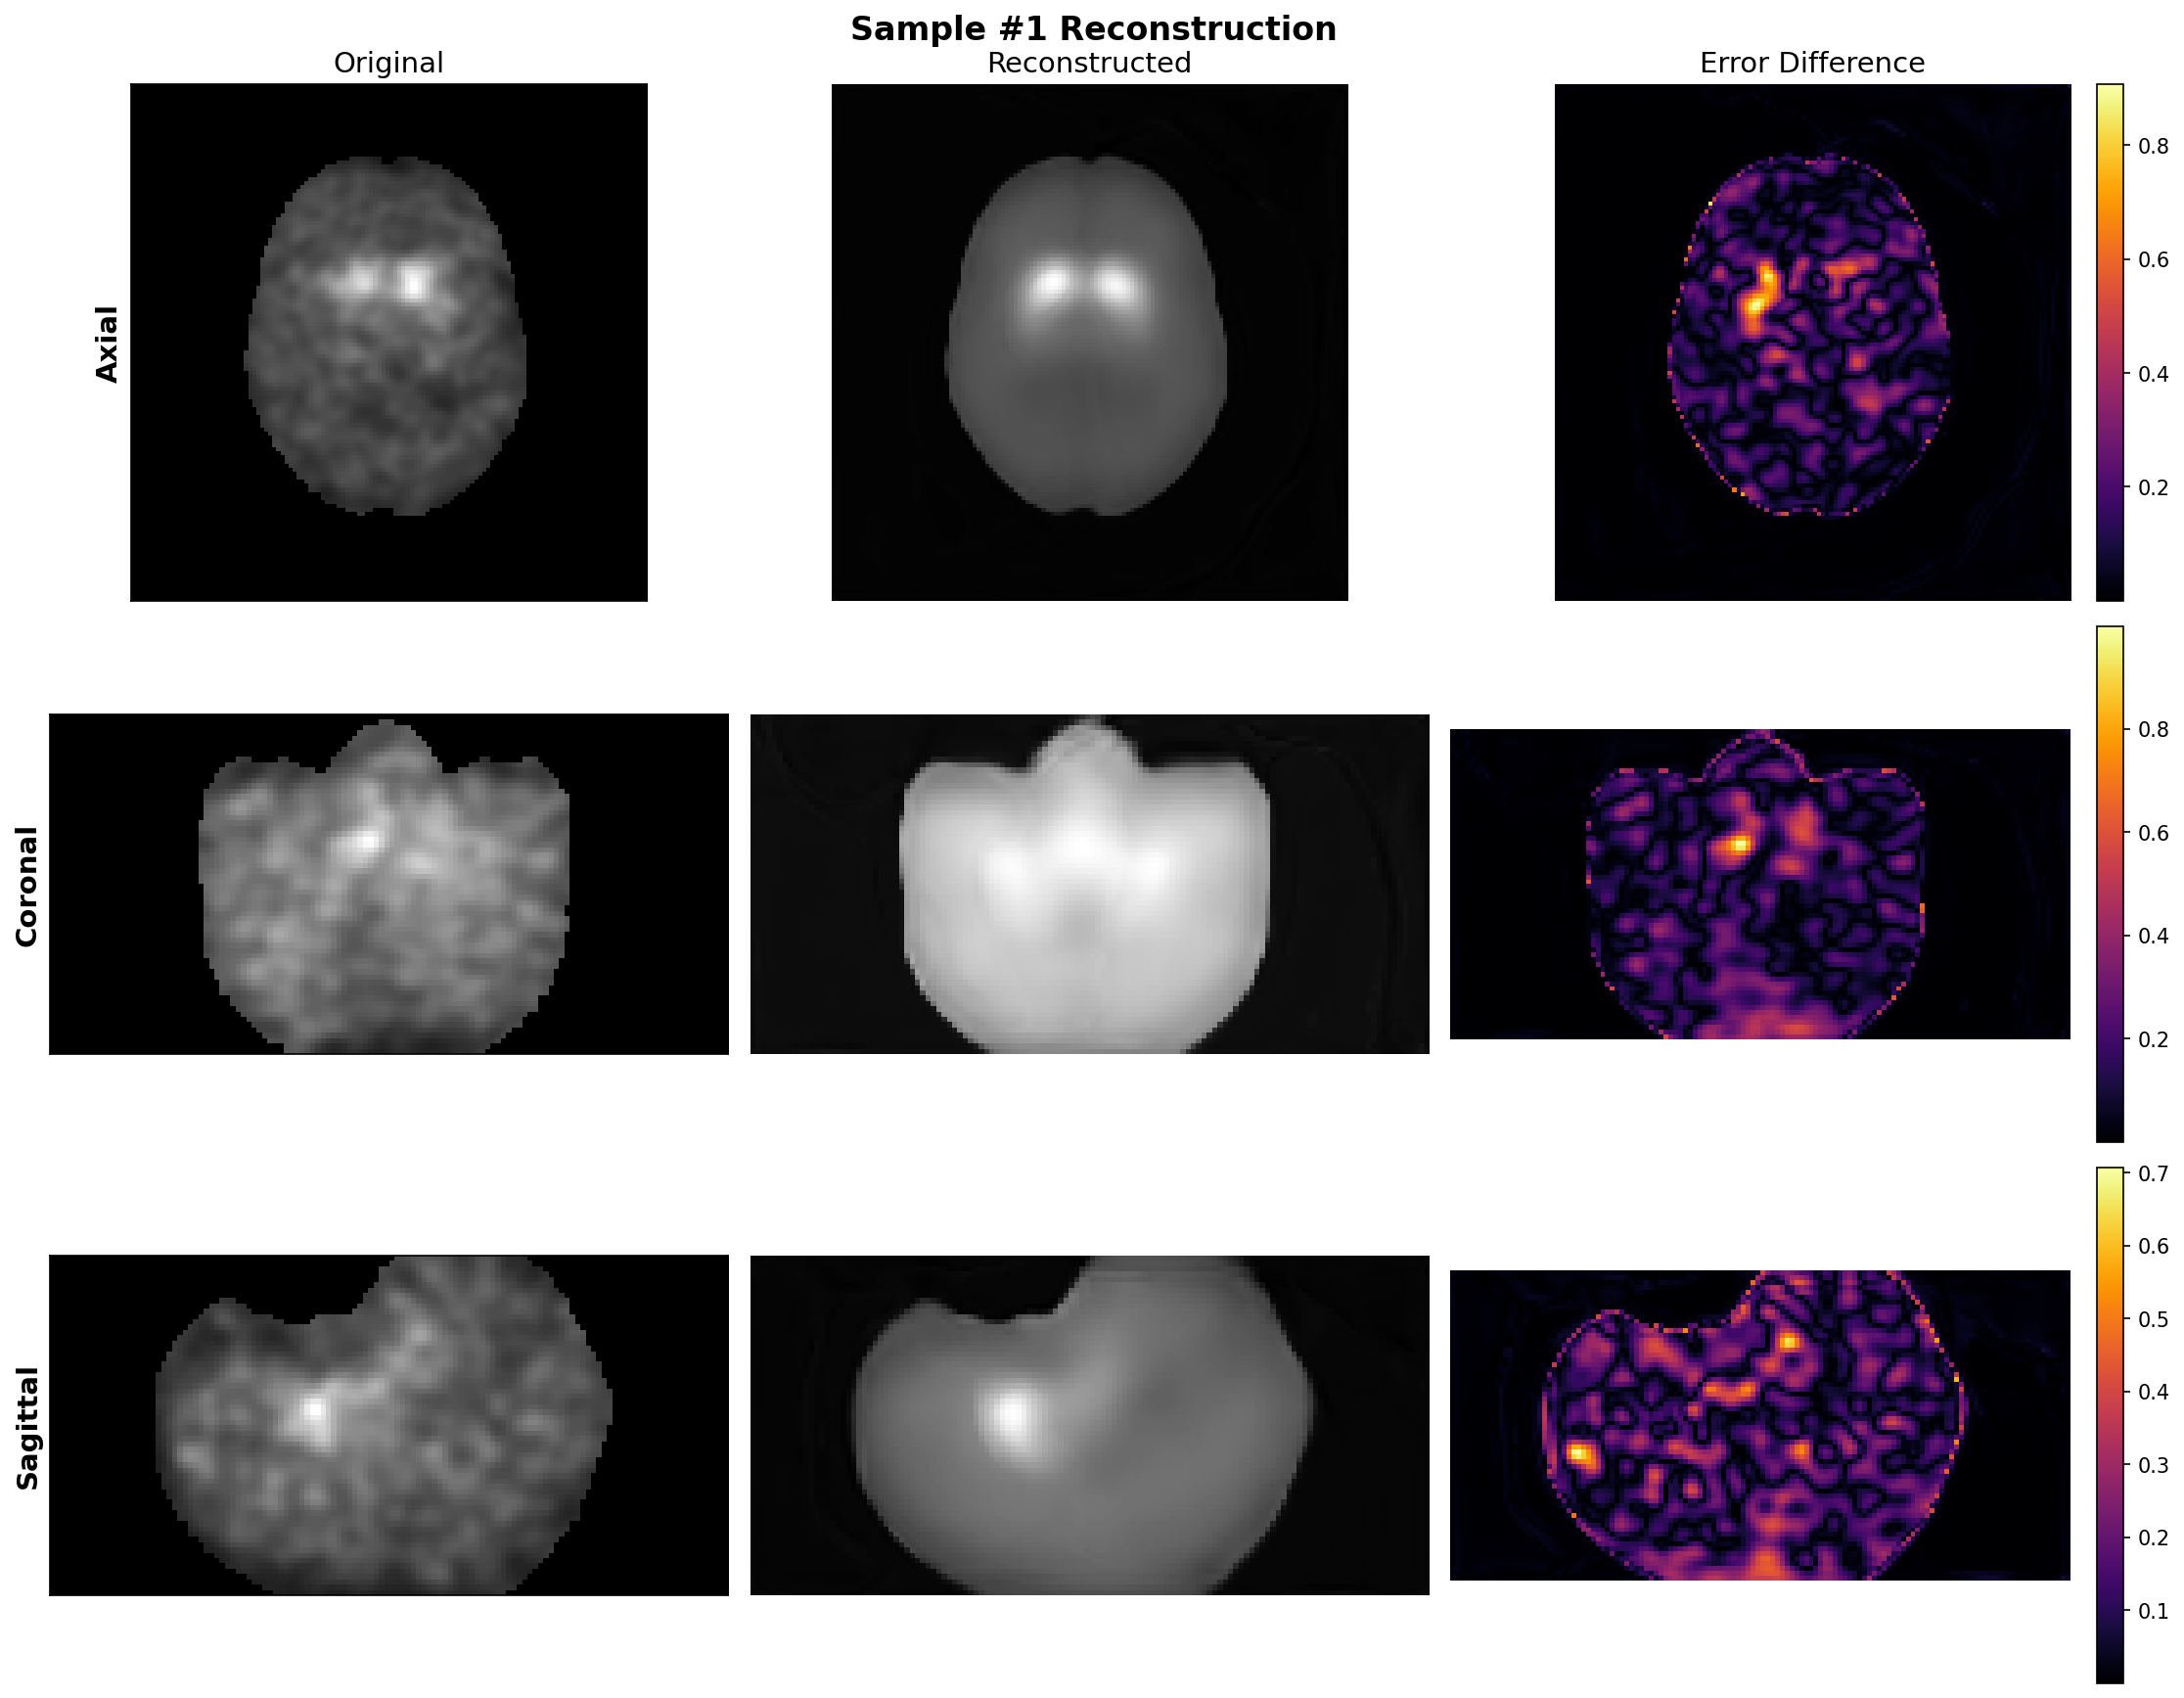

----------------------------------------------------------------------------------------------------


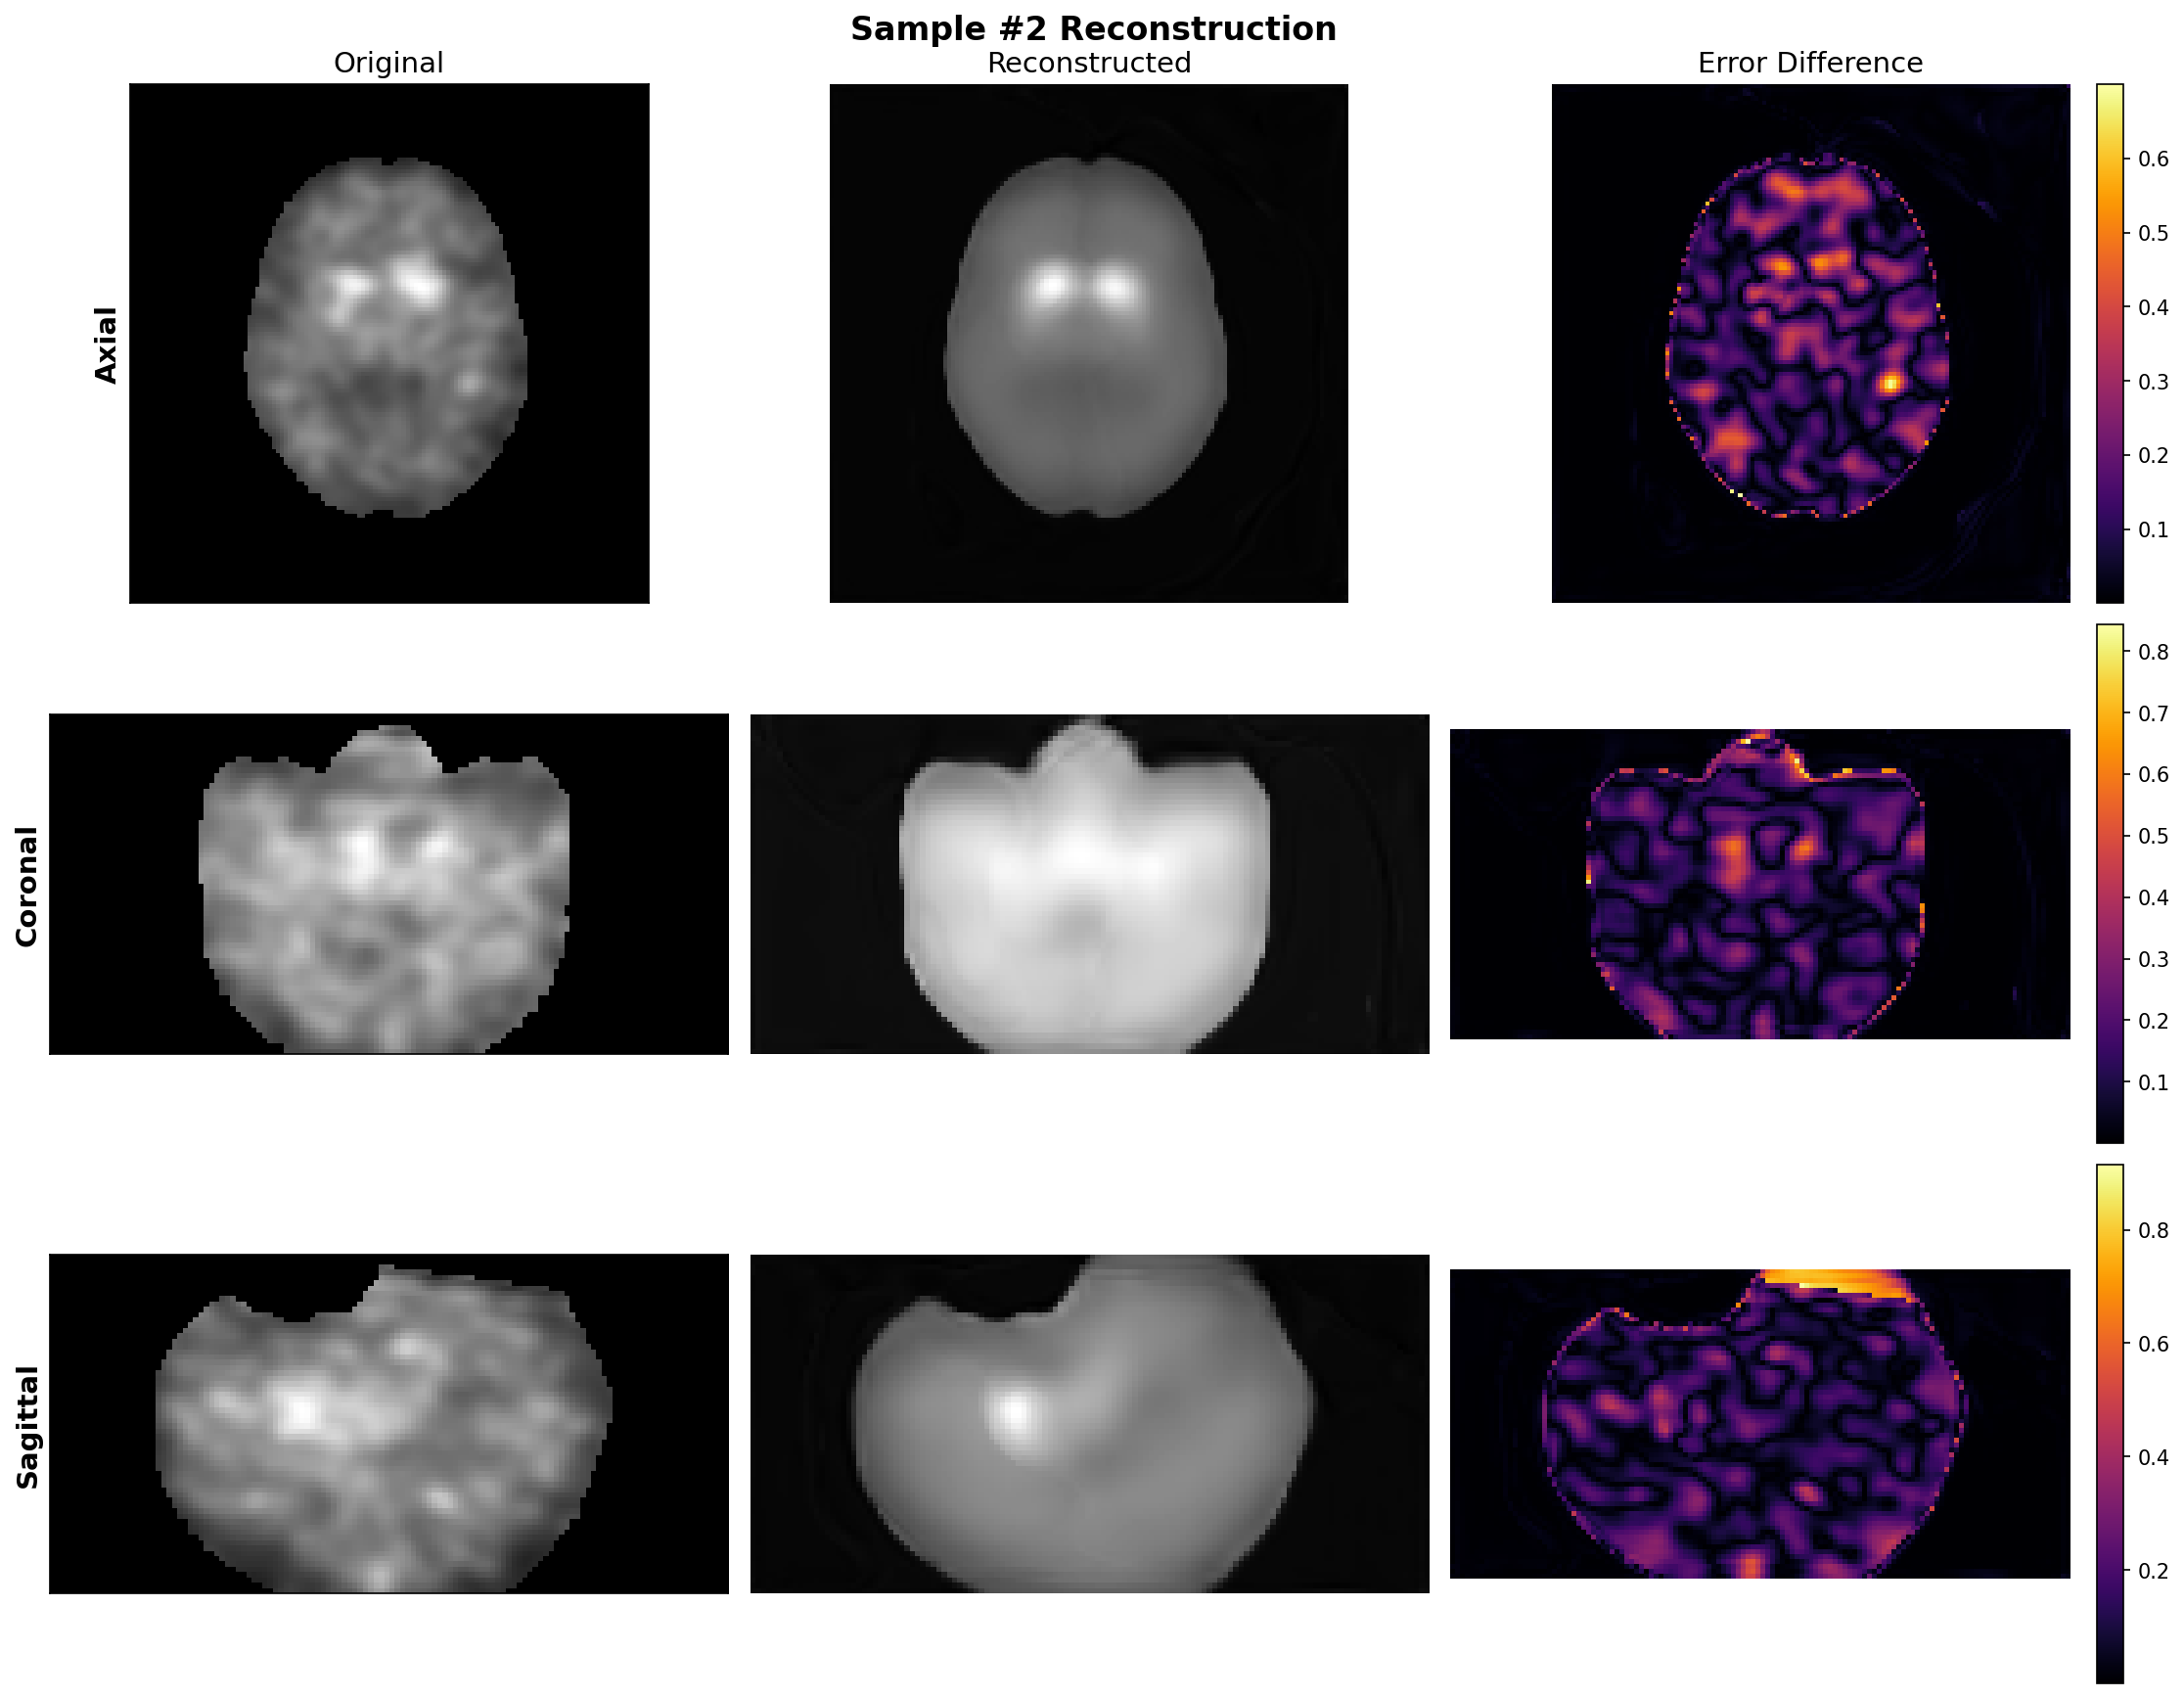

----------------------------------------------------------------------------------------------------


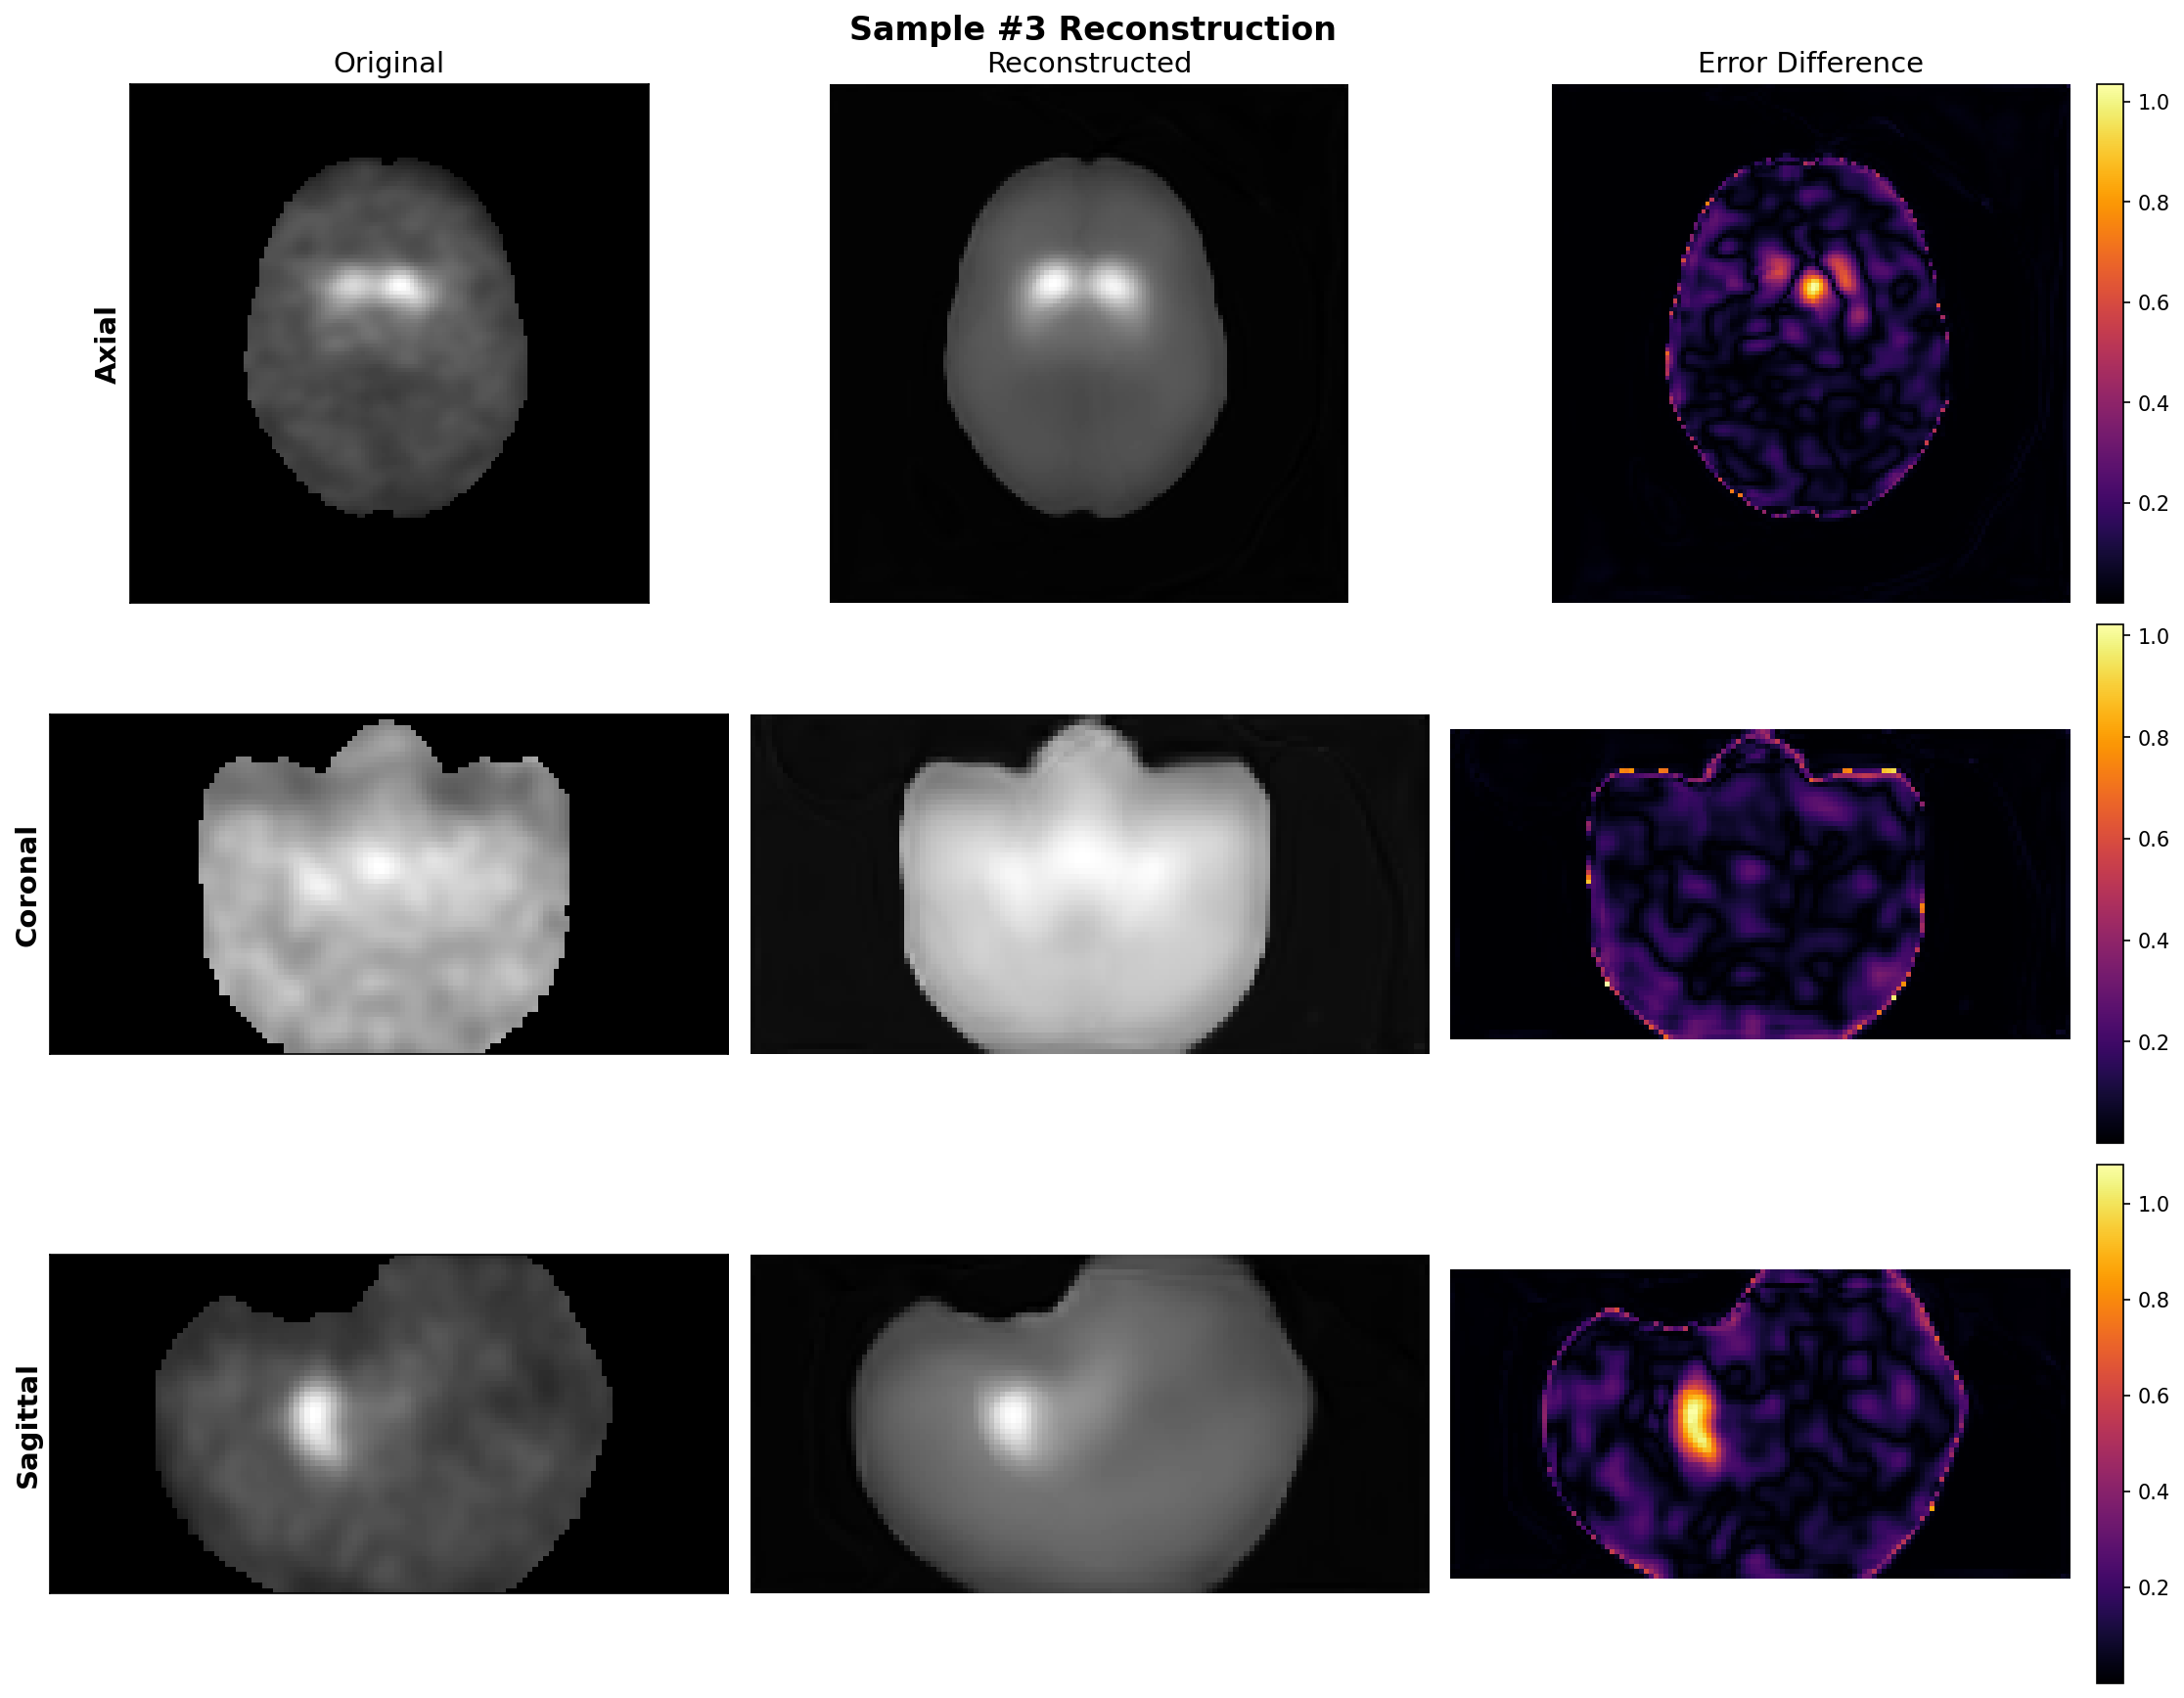

----------------------------------------------------------------------------------------------------


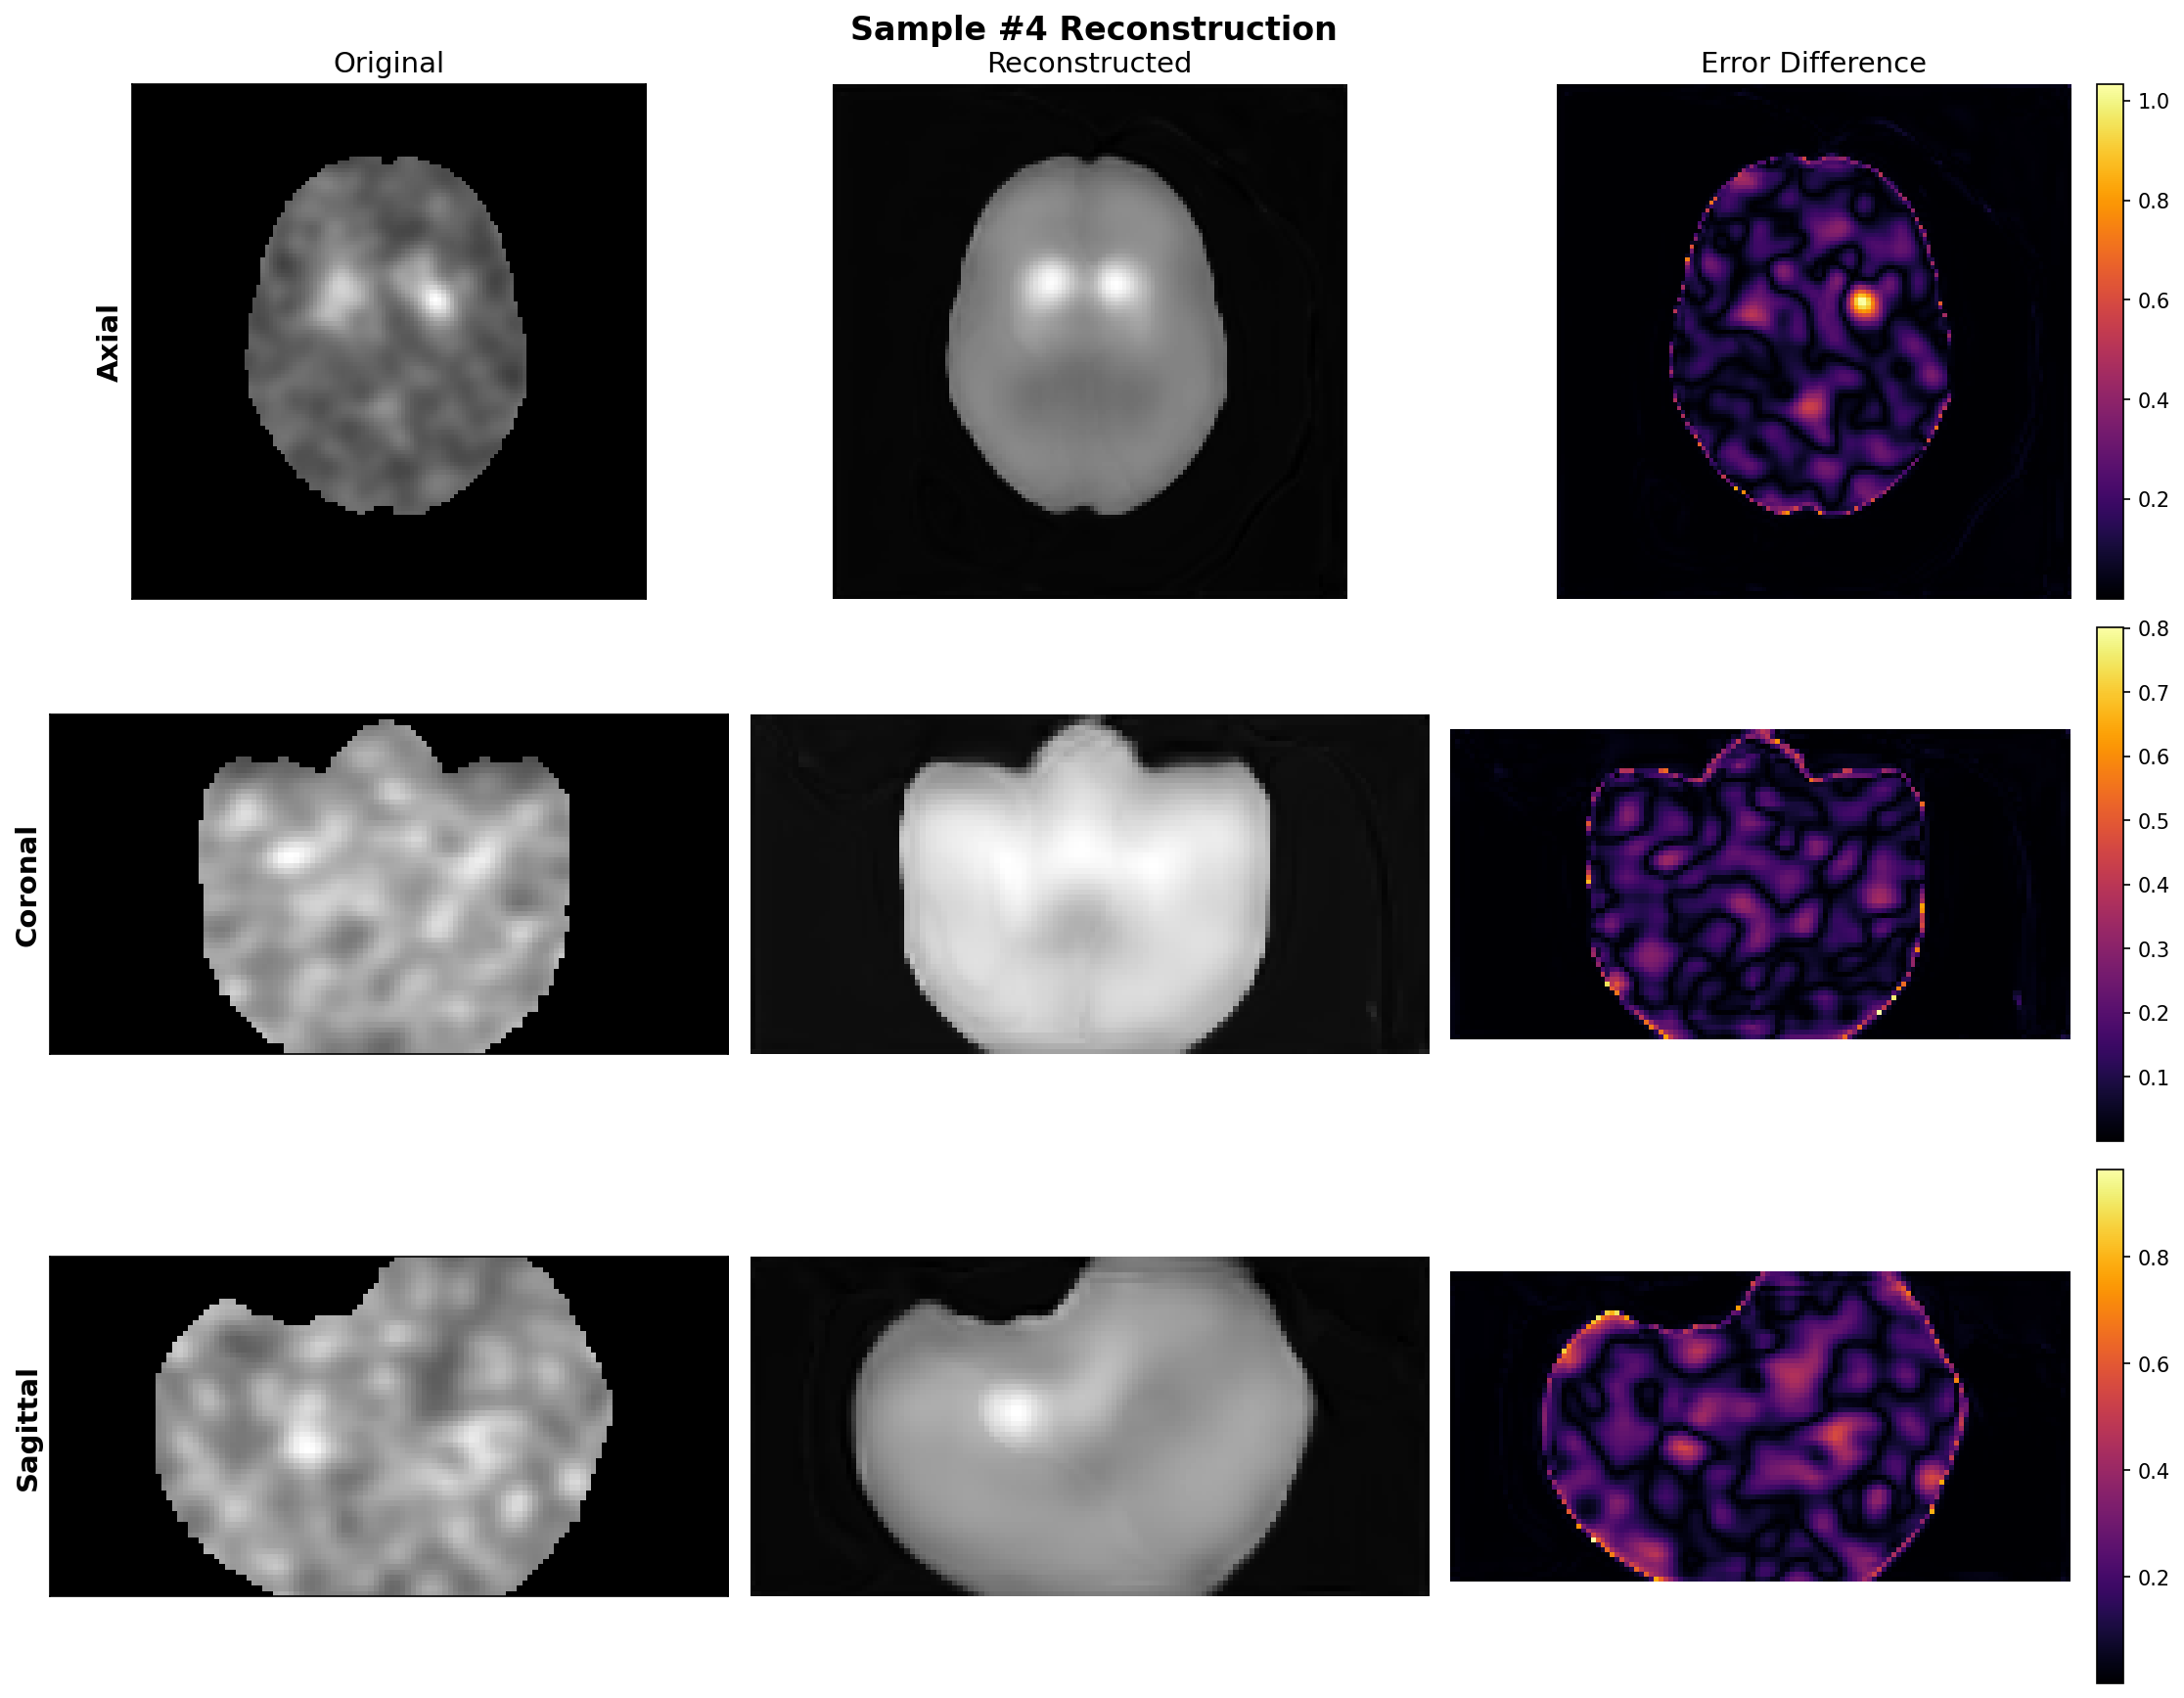

----------------------------------------------------------------------------------------------------


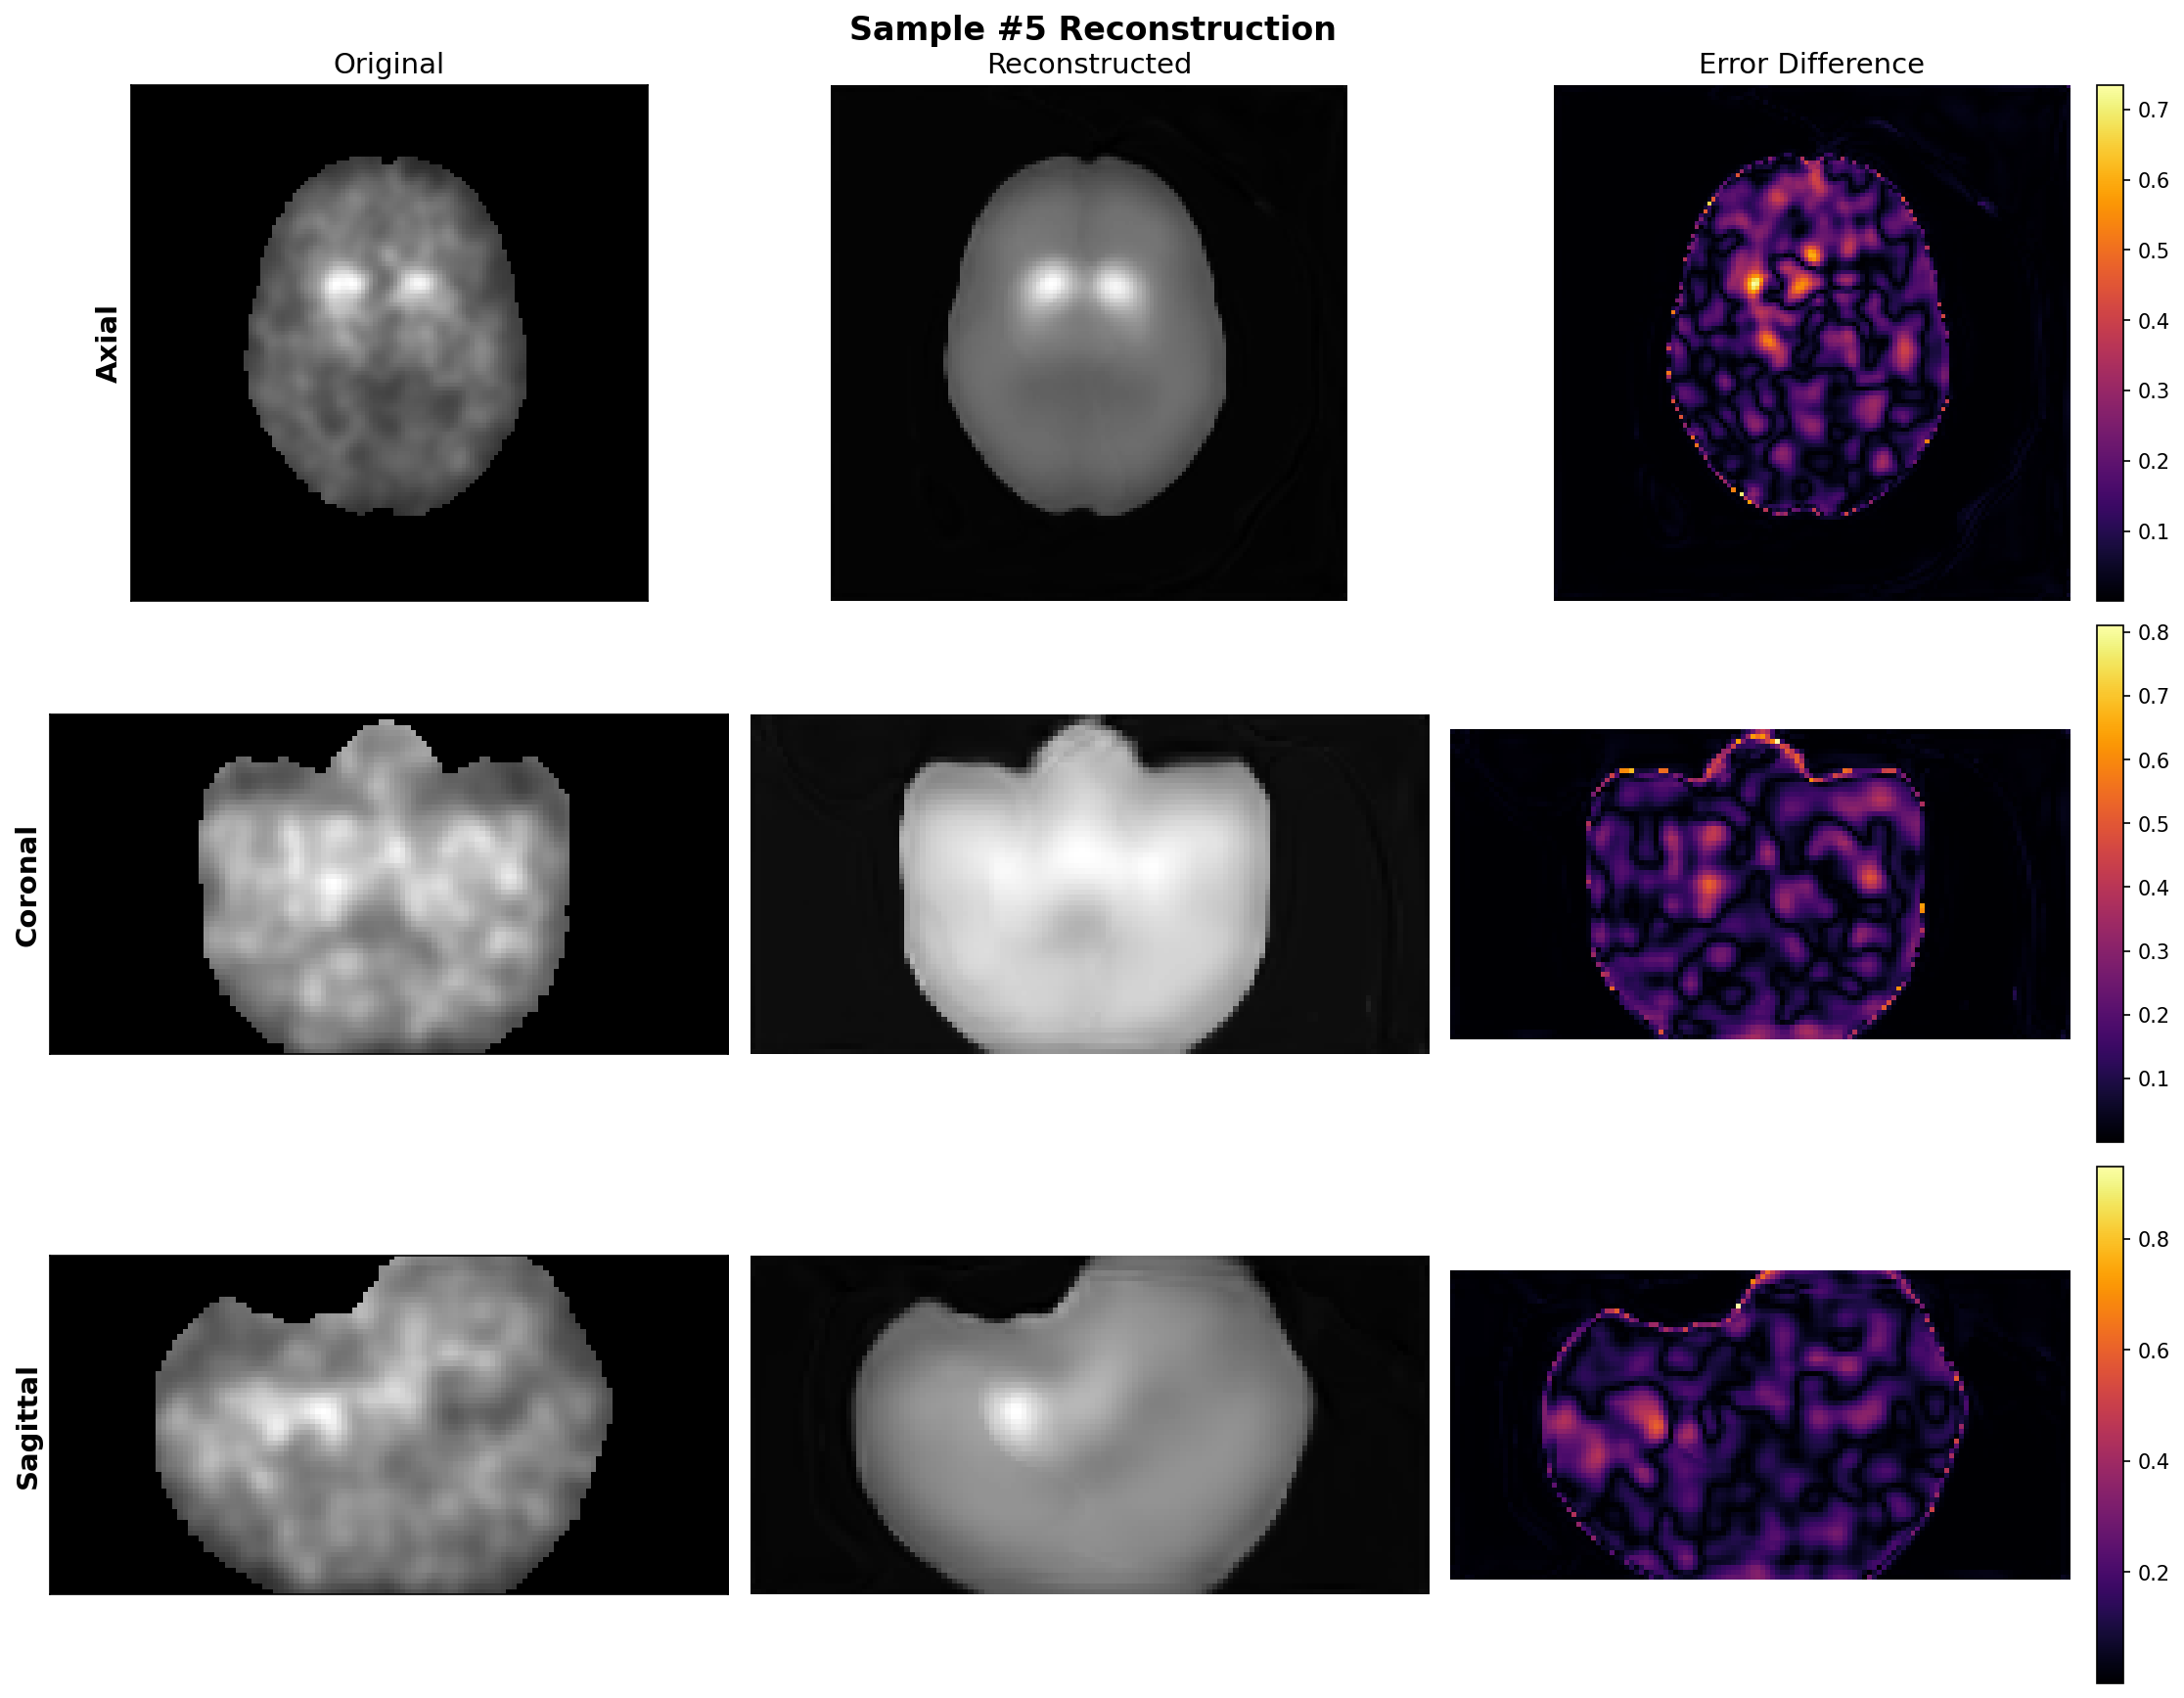

----------------------------------------------------------------------------------------------------


In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- Step 1: Collect 5 Samples ---
num_samples_needed = 5
collected_images = []

# Iterate through loader until we have enough images
iter_loader = iter(val_loader)
while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        # Check if batch is dict or tuple and extract volume
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break # Stop if dataset is exhausted

# Stack and select exactly 5
if len(collected_images) < num_samples_needed:
    print(f"Warning: Only found {len(collected_images)} samples.")
    num_samples_needed = len(collected_images)

sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- Step 2: Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- Step 3: Visualization Loop ---
# Define slices (Depth, Height, Width)
slices_indices = {
    'Axial': (0, 32),    # dim 0
    'Coronal': (1, 64),  # dim 1
    'Sagittal': (2, 64)  # dim 2
}
views = ['Axial', 'Coronal', 'Sagittal']

def get_slice(data, dim, idx):
    if dim == 0: return data[idx, :, :]
    if dim == 1: return data[:, idx, :]
    if dim == 2: return data[:, :, idx]

# Loop through each sample and create a separate figure
for i in range(num_samples_needed):
    
    # Extract single sample (CPU numpy)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create a new Figure for this sample
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} Reconstruction", fontsize=16, weight='bold', y=0.96)
    
    for row_idx, view_name in enumerate(views):
        dim_idx, slice_idx = slices_indices[view_name]
        
        # Get slices
        orig_slice = get_slice(orig_np, dim_idx, slice_idx)
        recon_slice = get_slice(recon_np, dim_idx, slice_idx)
        error_slice = np.abs(orig_slice - recon_slice)
        
        # Column 1: Original
        axes[row_idx, 0].imshow(orig_slice, cmap='gray')
        axes[row_idx, 0].set_ylabel(view_name, fontsize=14, weight='bold') # Label the row
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # Column 2: Reconstructed
        axes[row_idx, 1].imshow(recon_slice, cmap='gray')
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # Column 3: Error
        im = axes[row_idx, 2].imshow(error_slice, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Add a colorbar specifically for the error plot
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Make room for main title
    plt.show()
    print("-" * 100) # Separator line

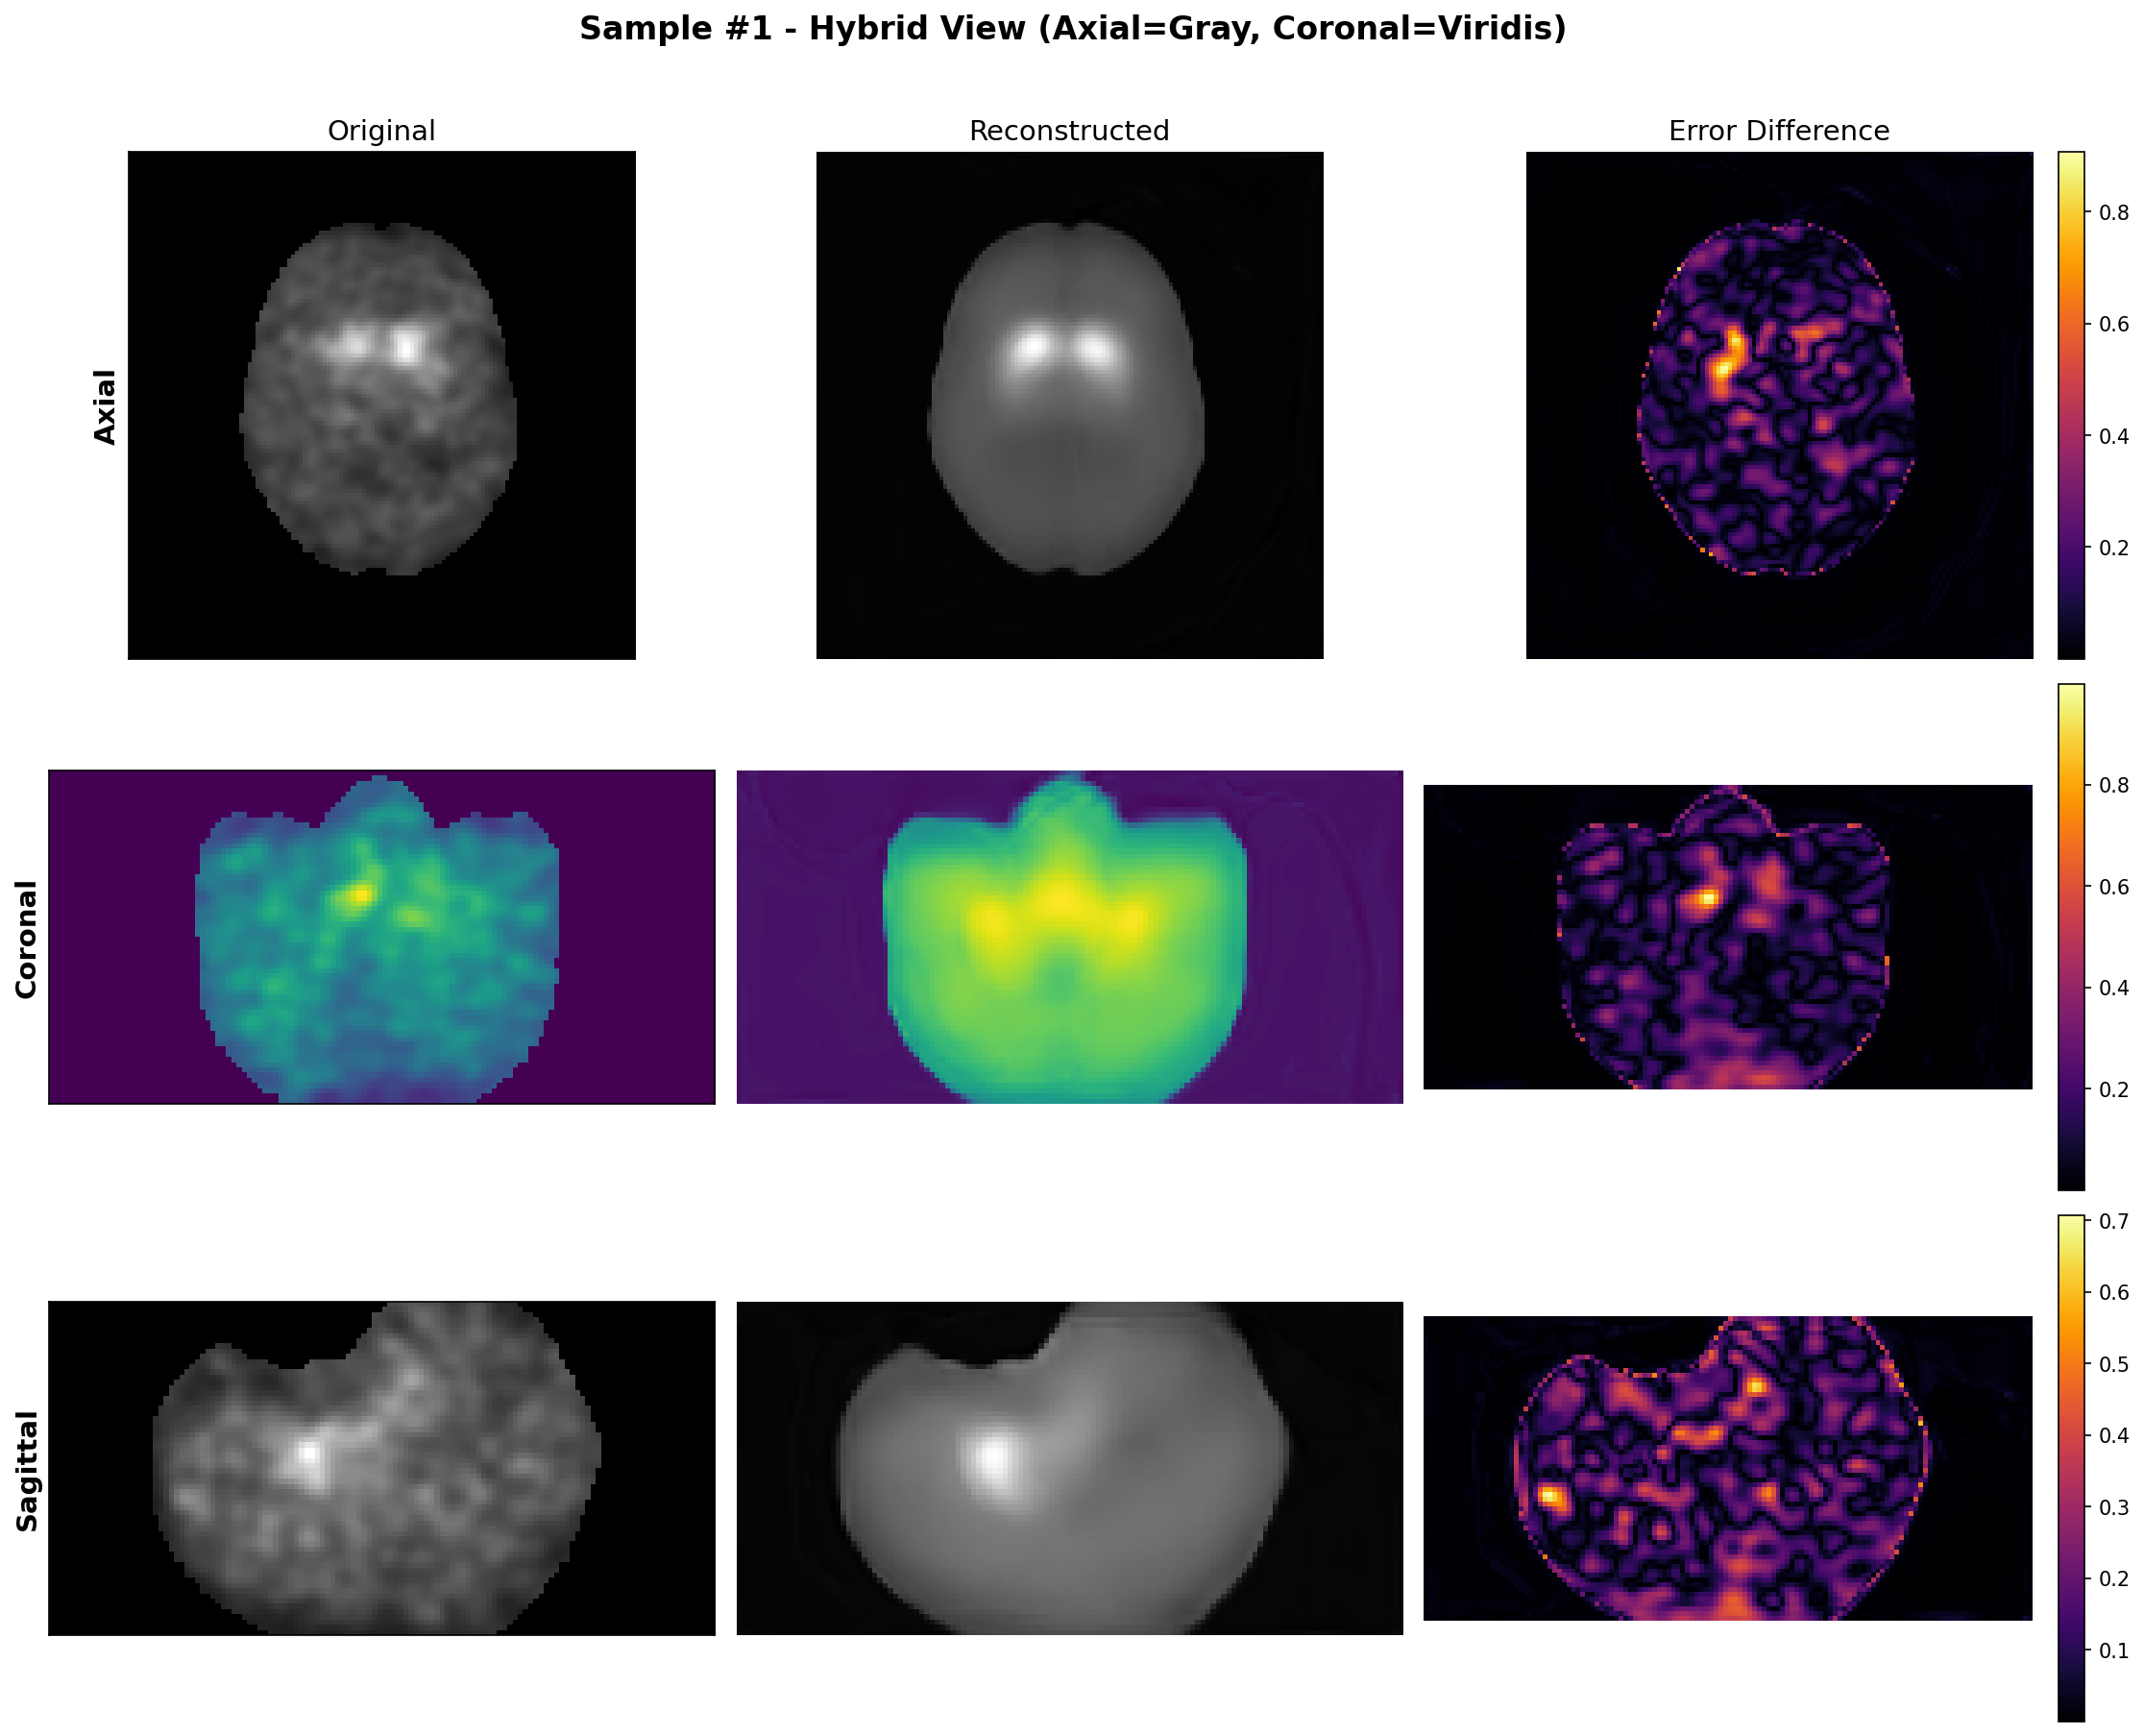

----------------------------------------------------------------------------------------------------


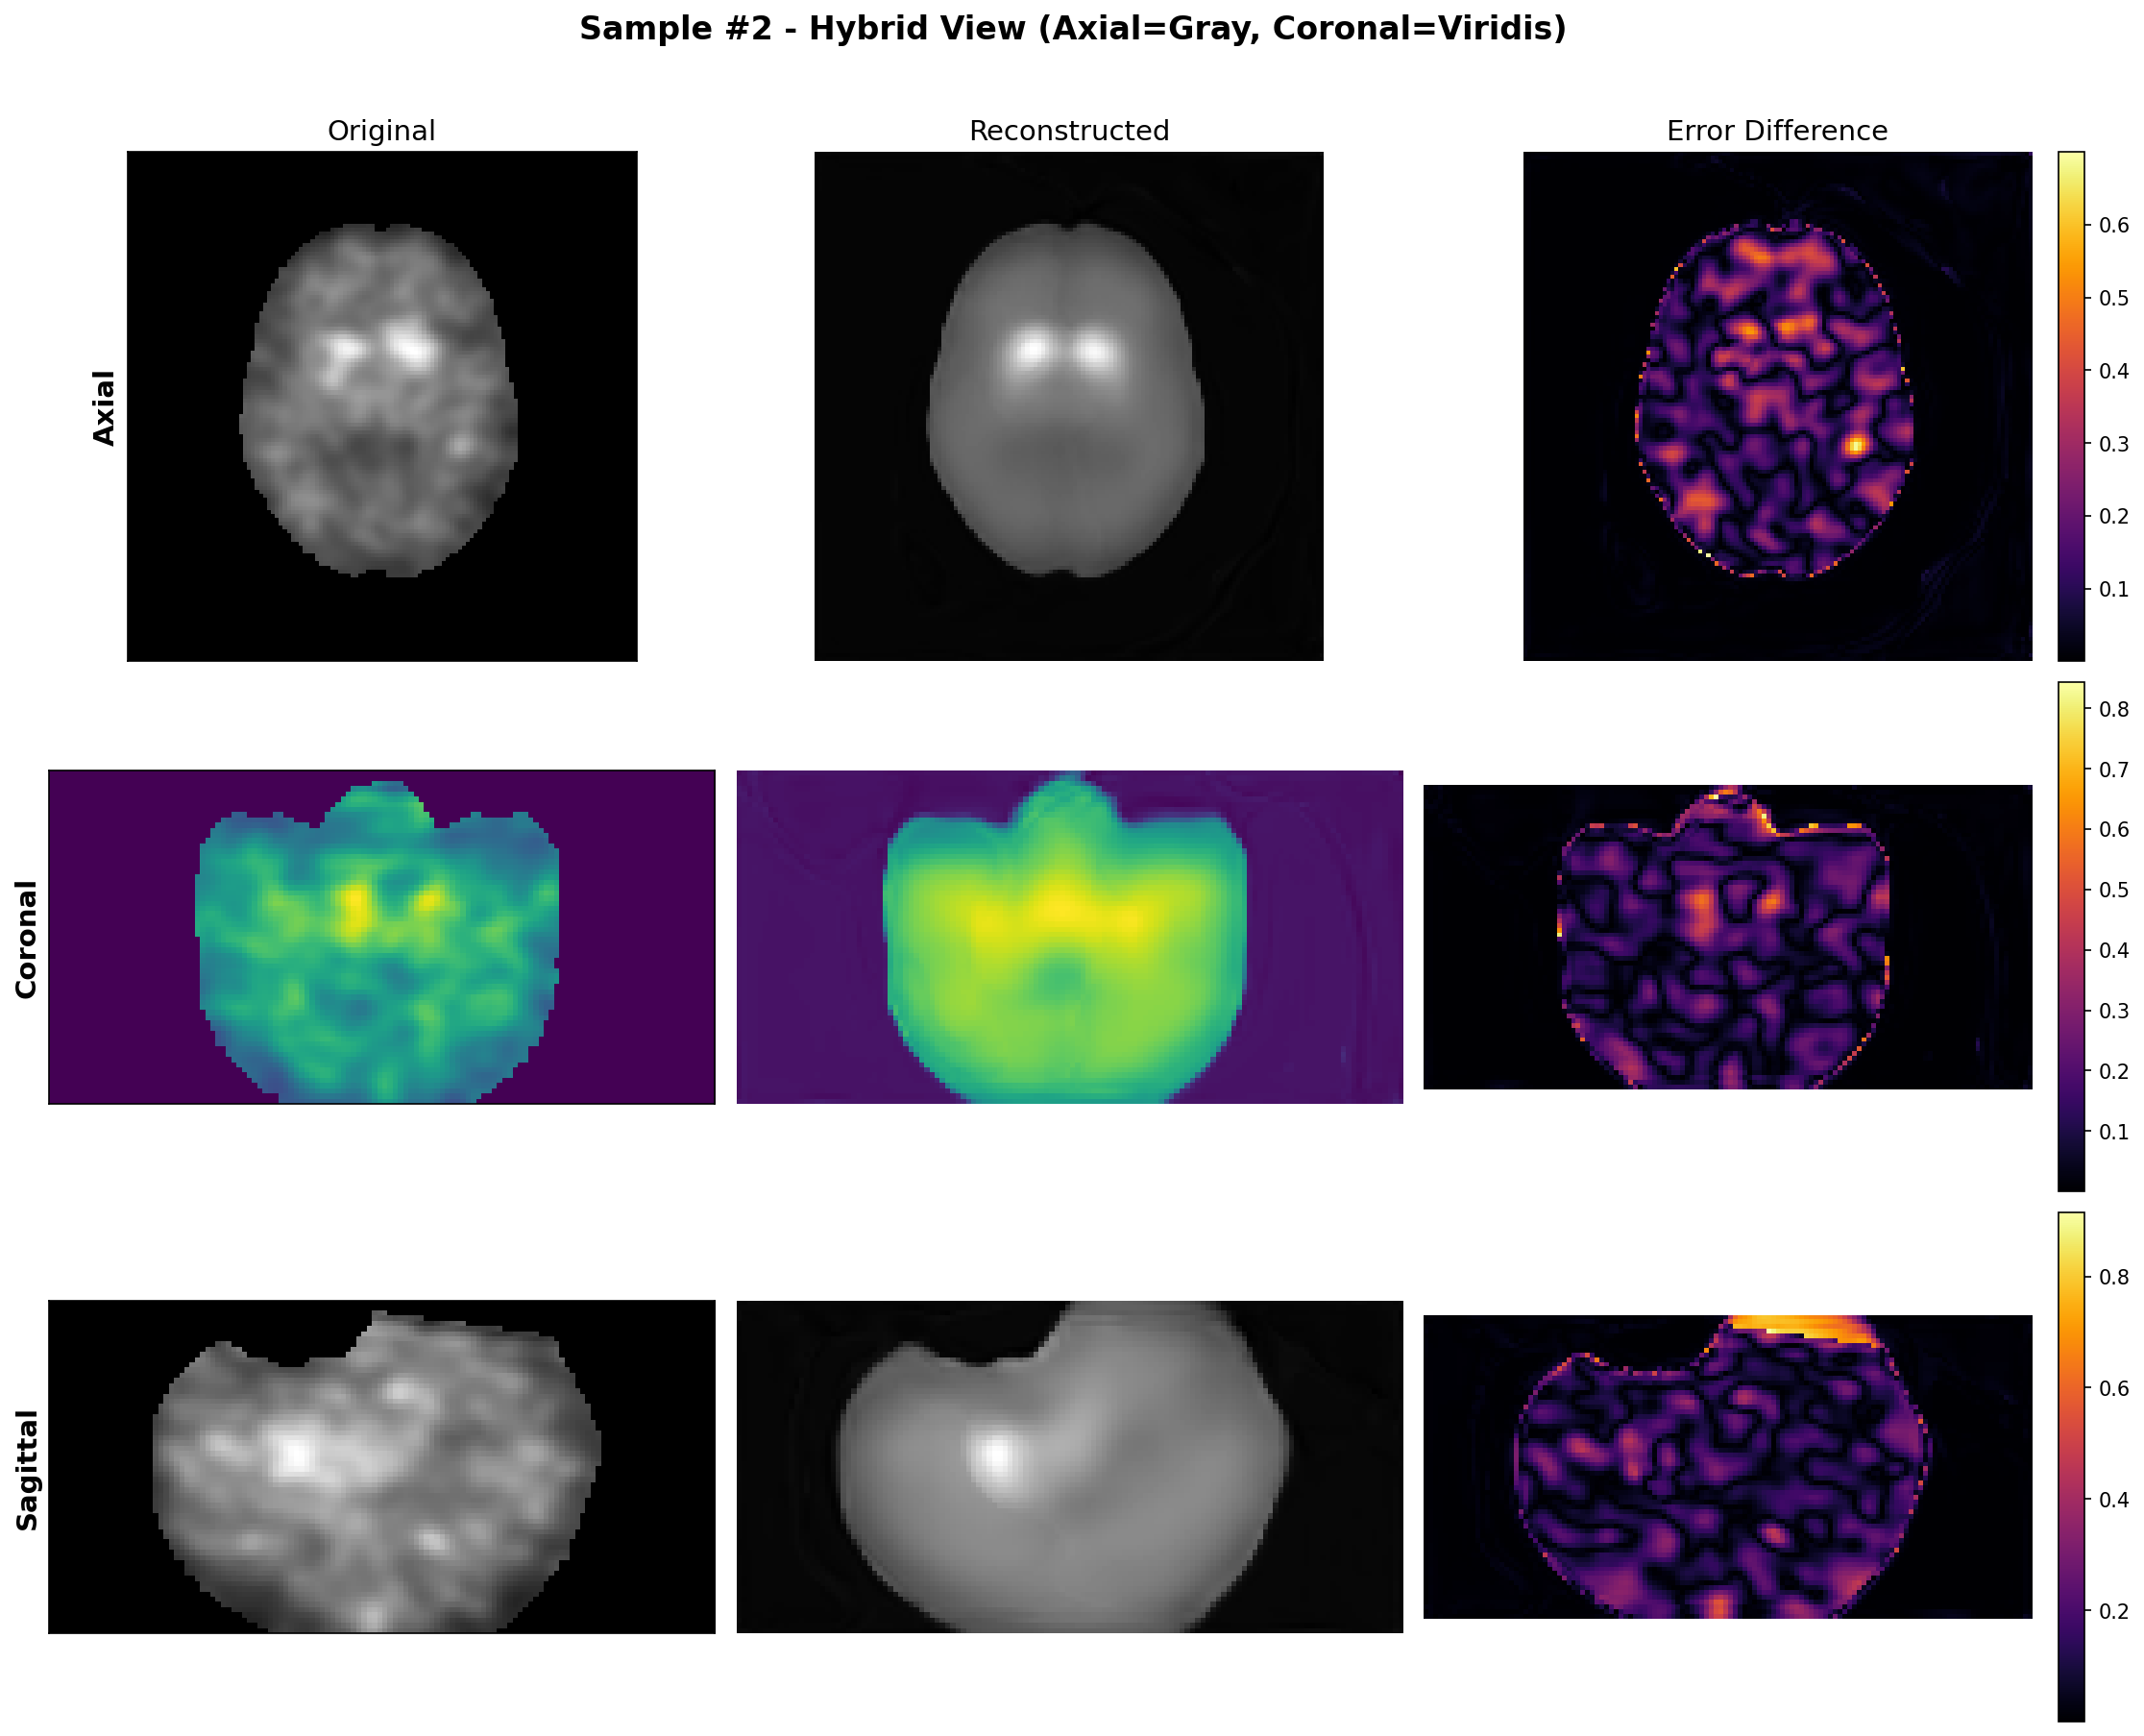

----------------------------------------------------------------------------------------------------


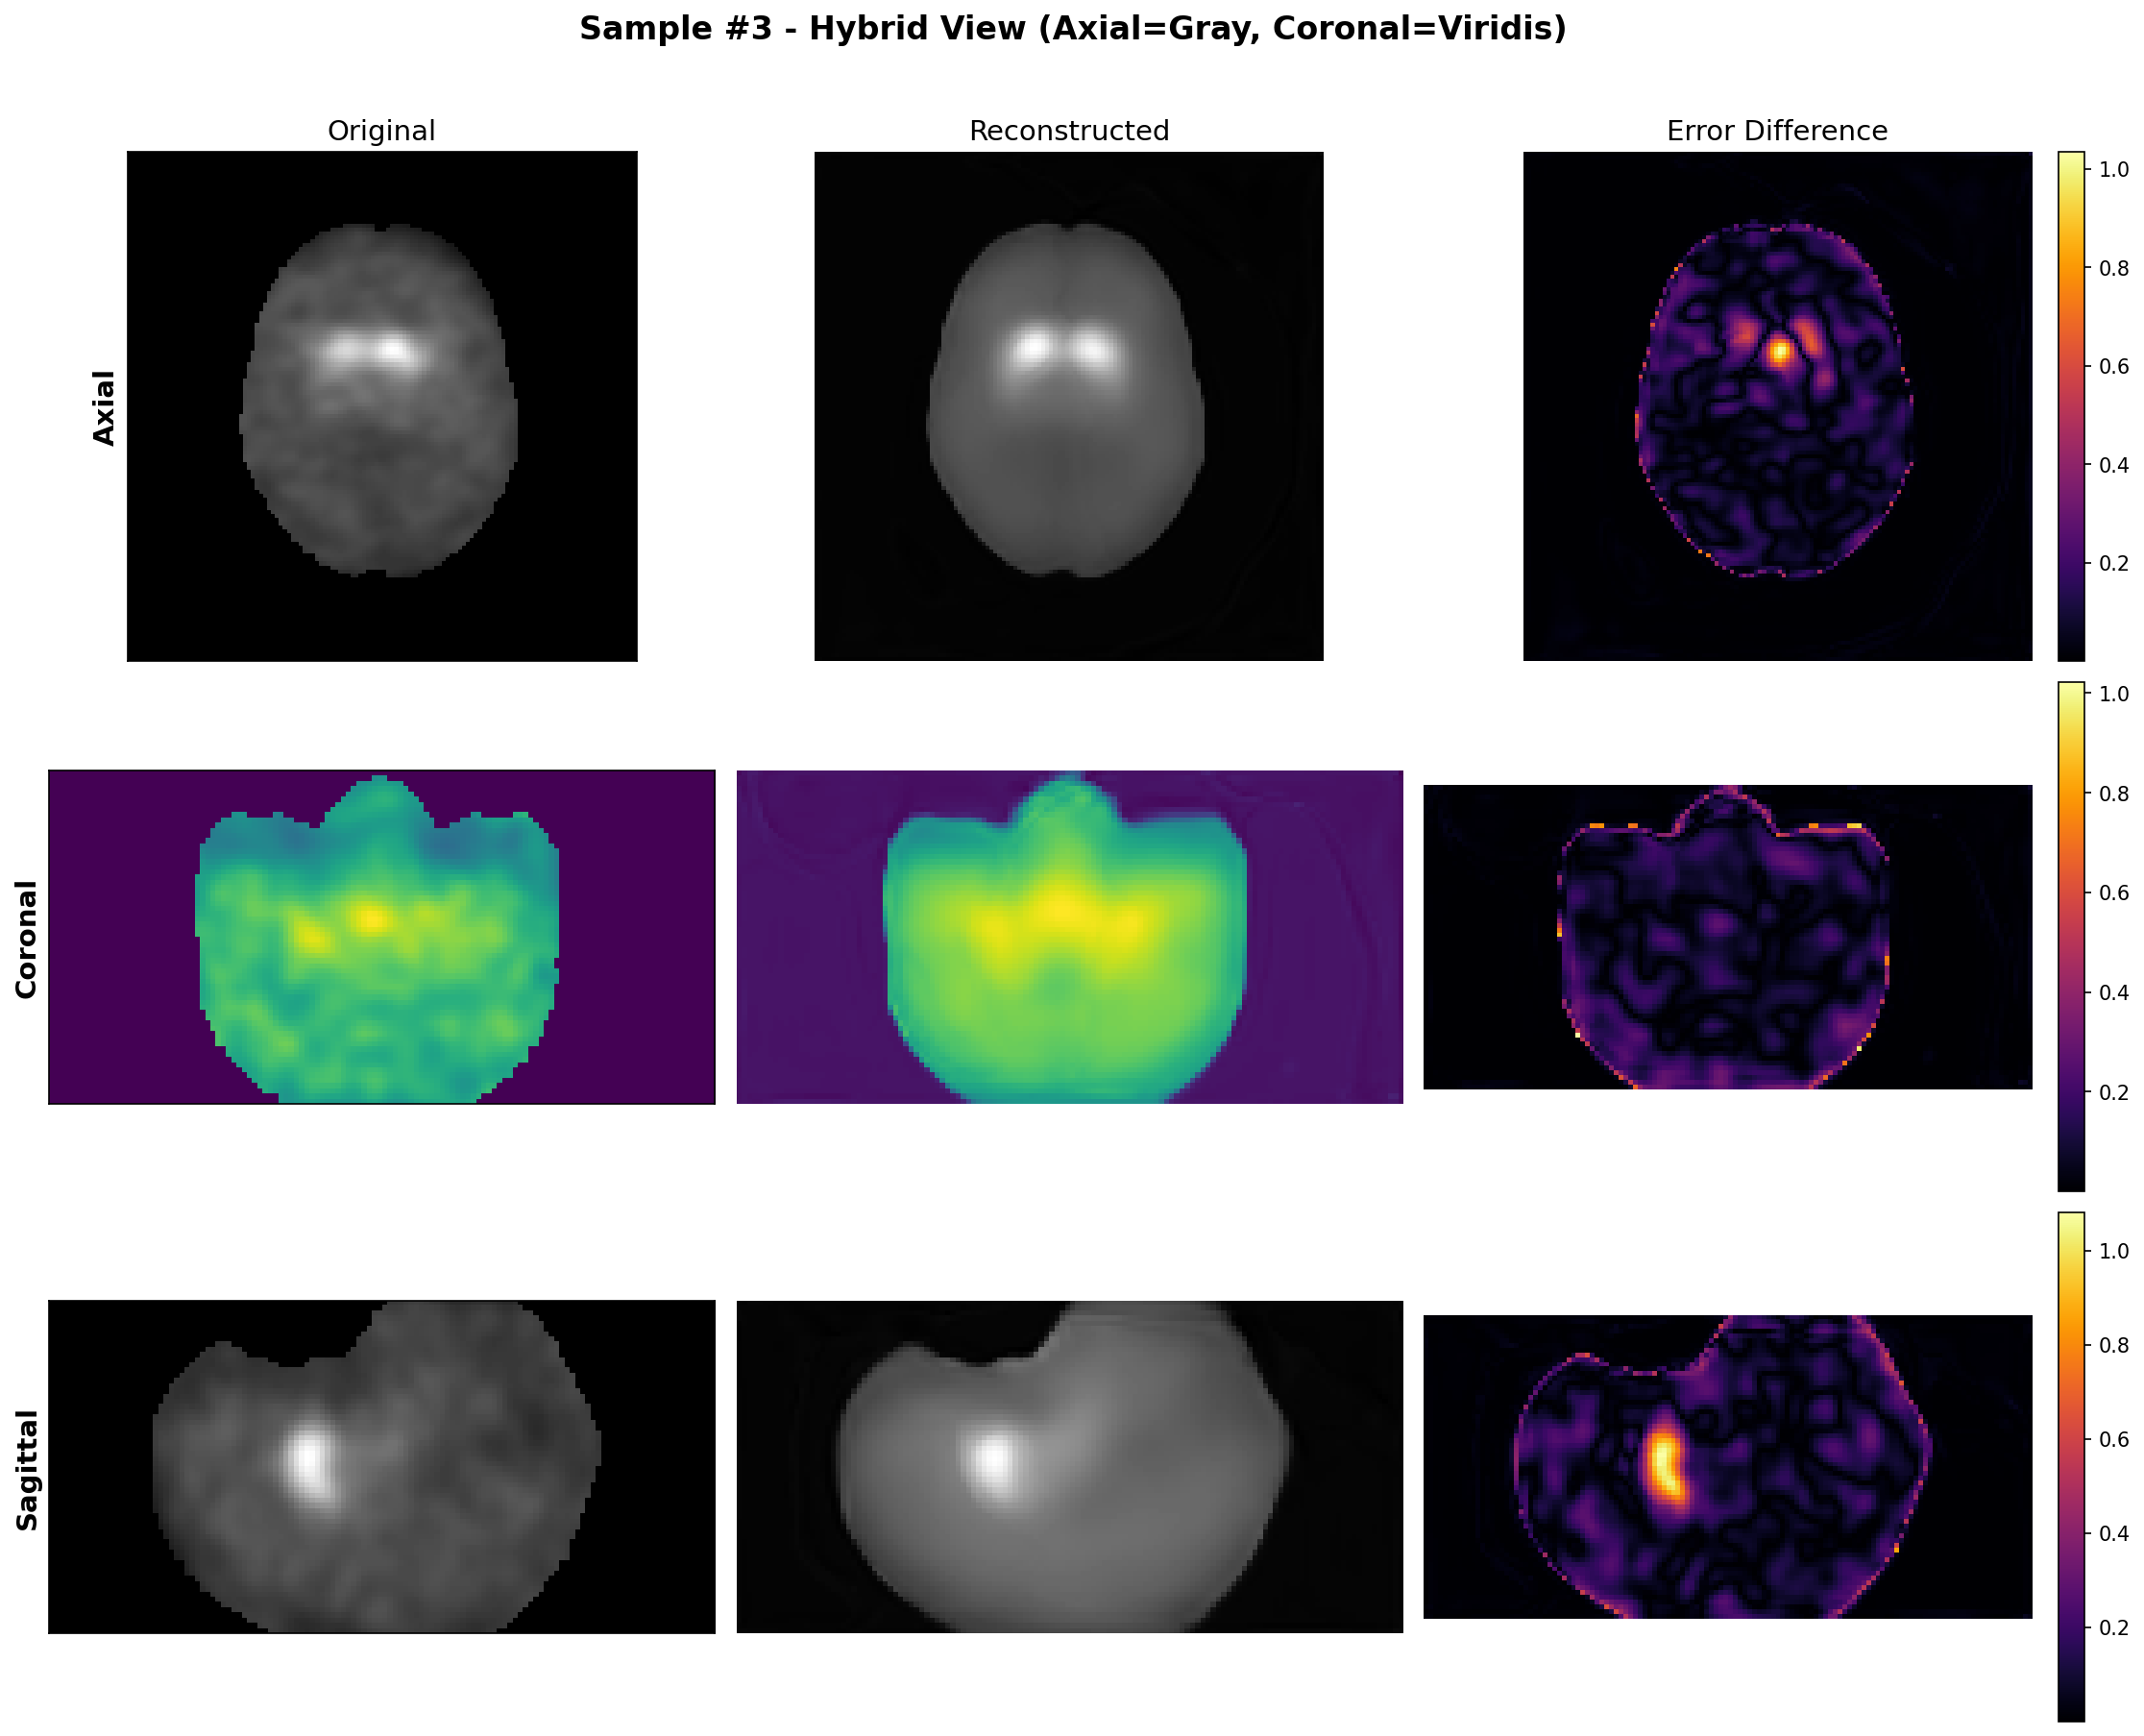

----------------------------------------------------------------------------------------------------


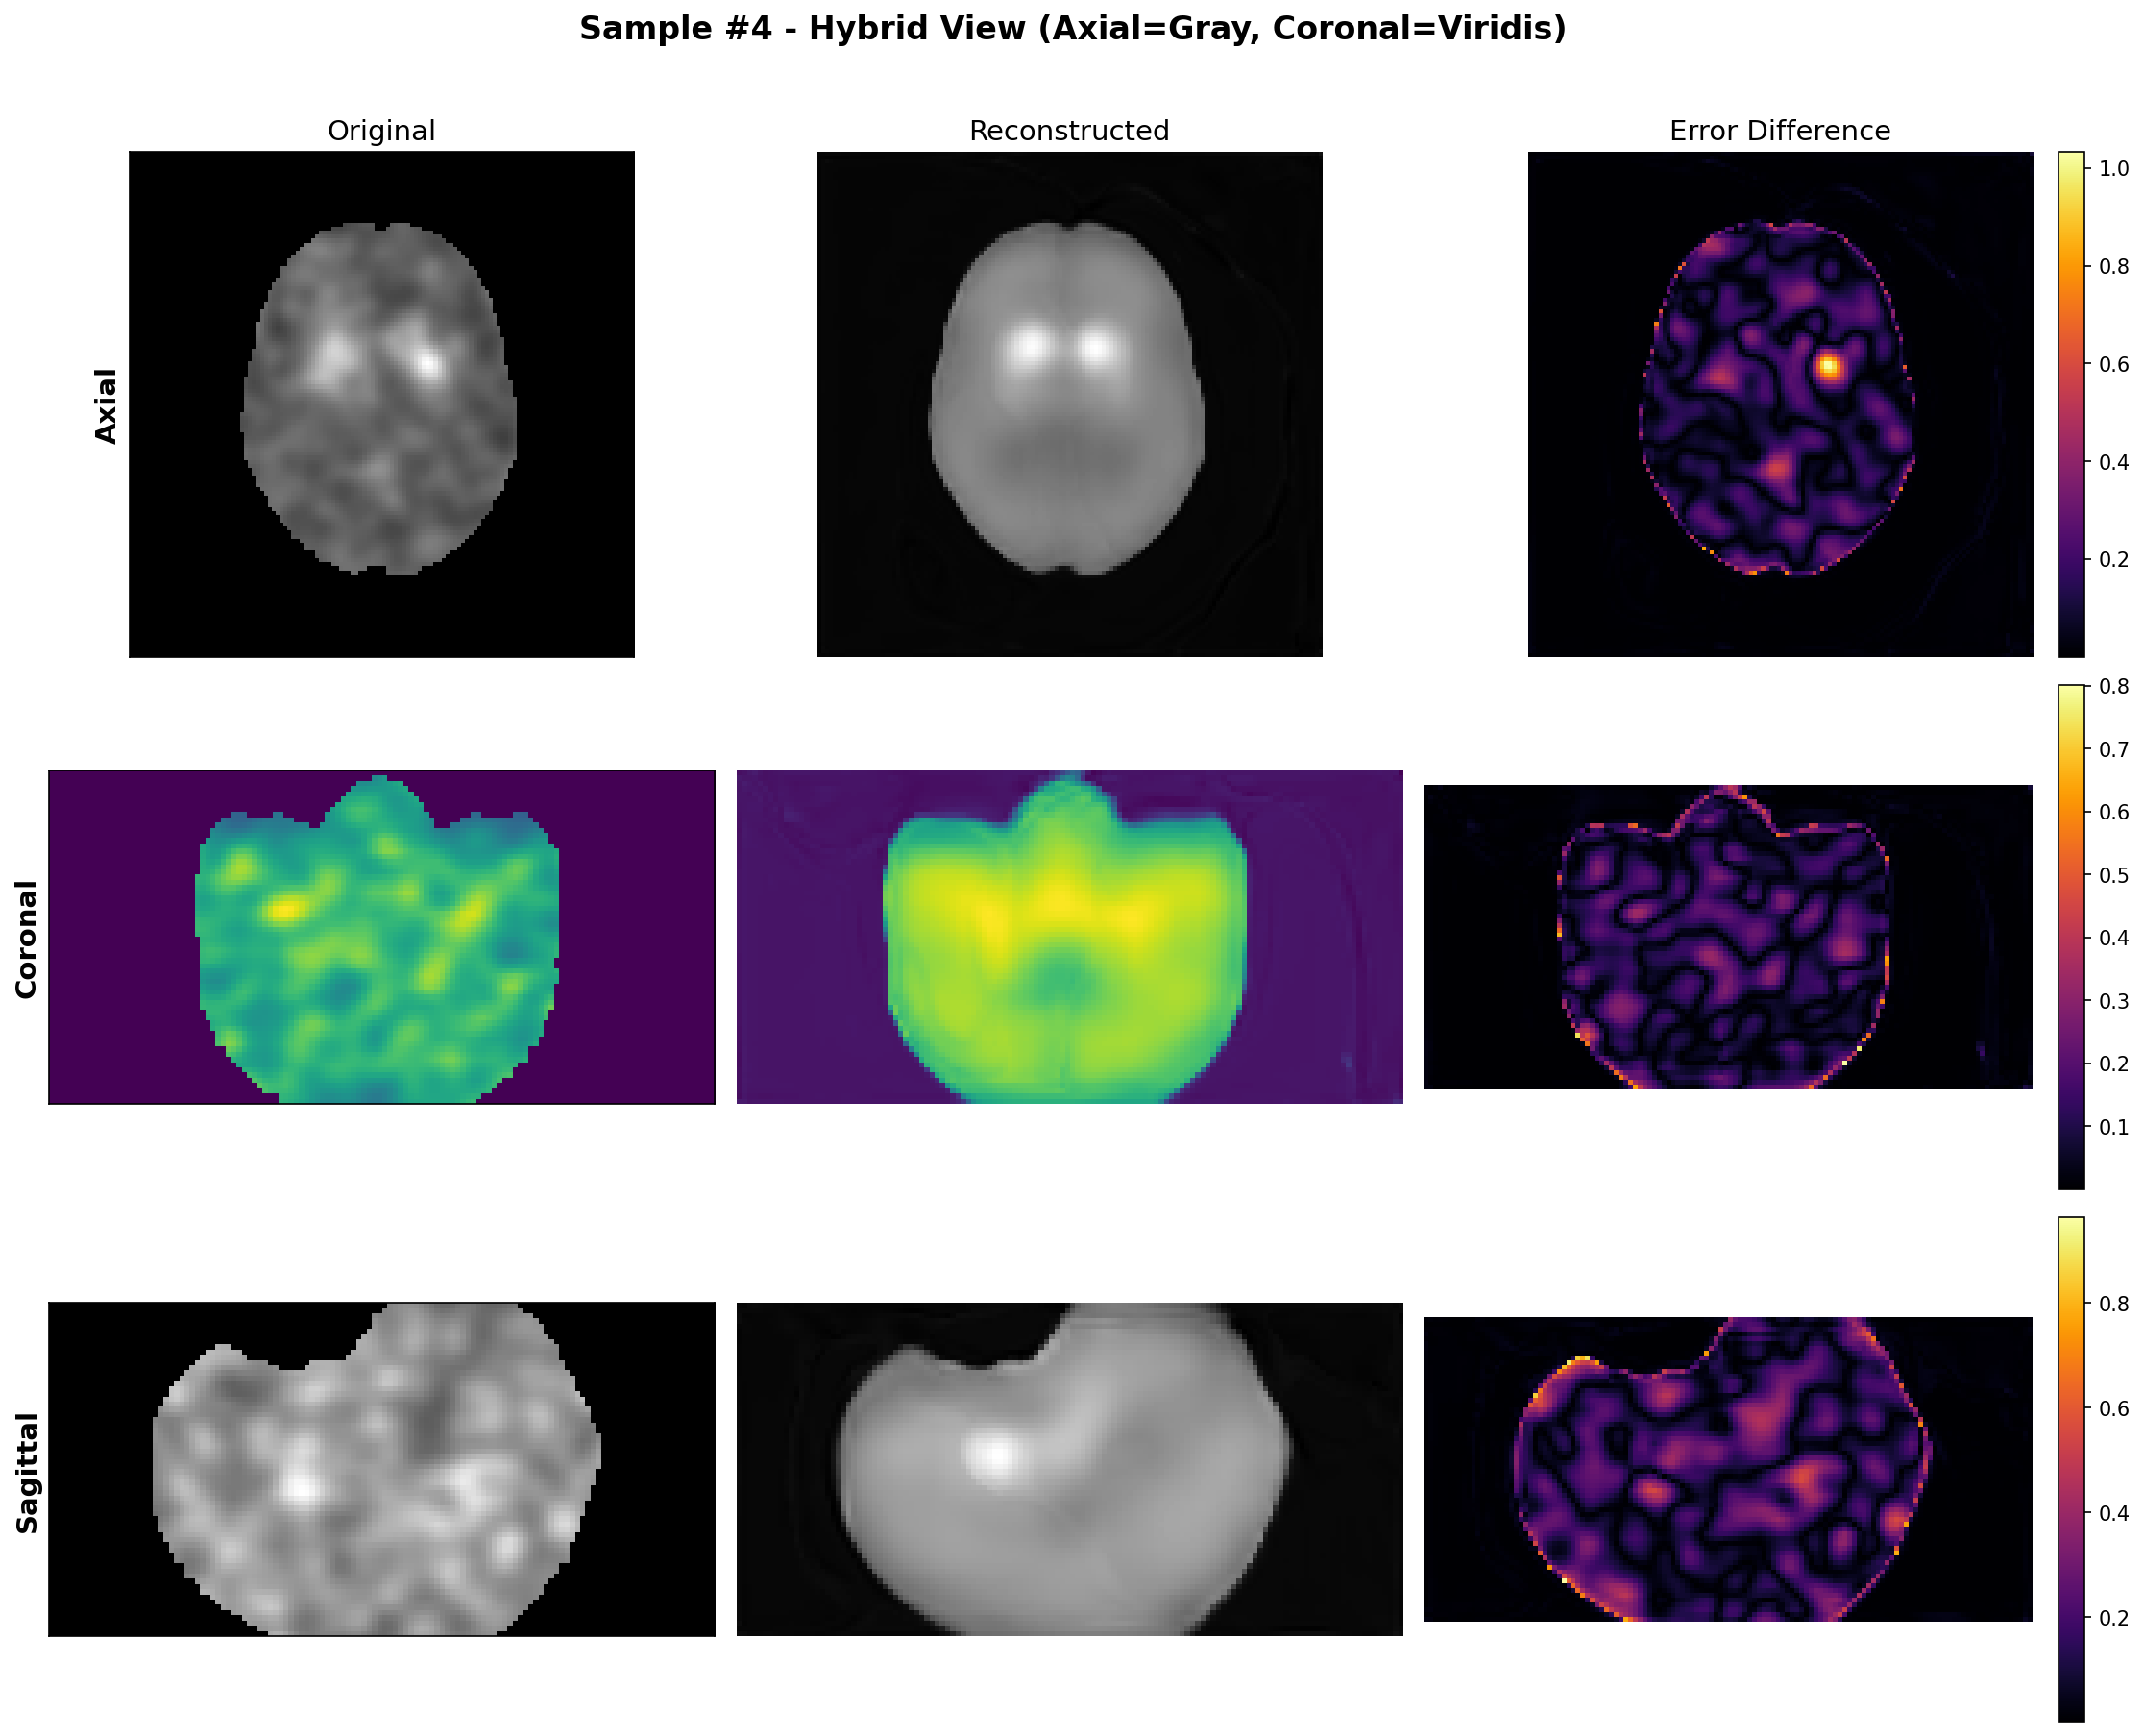

----------------------------------------------------------------------------------------------------


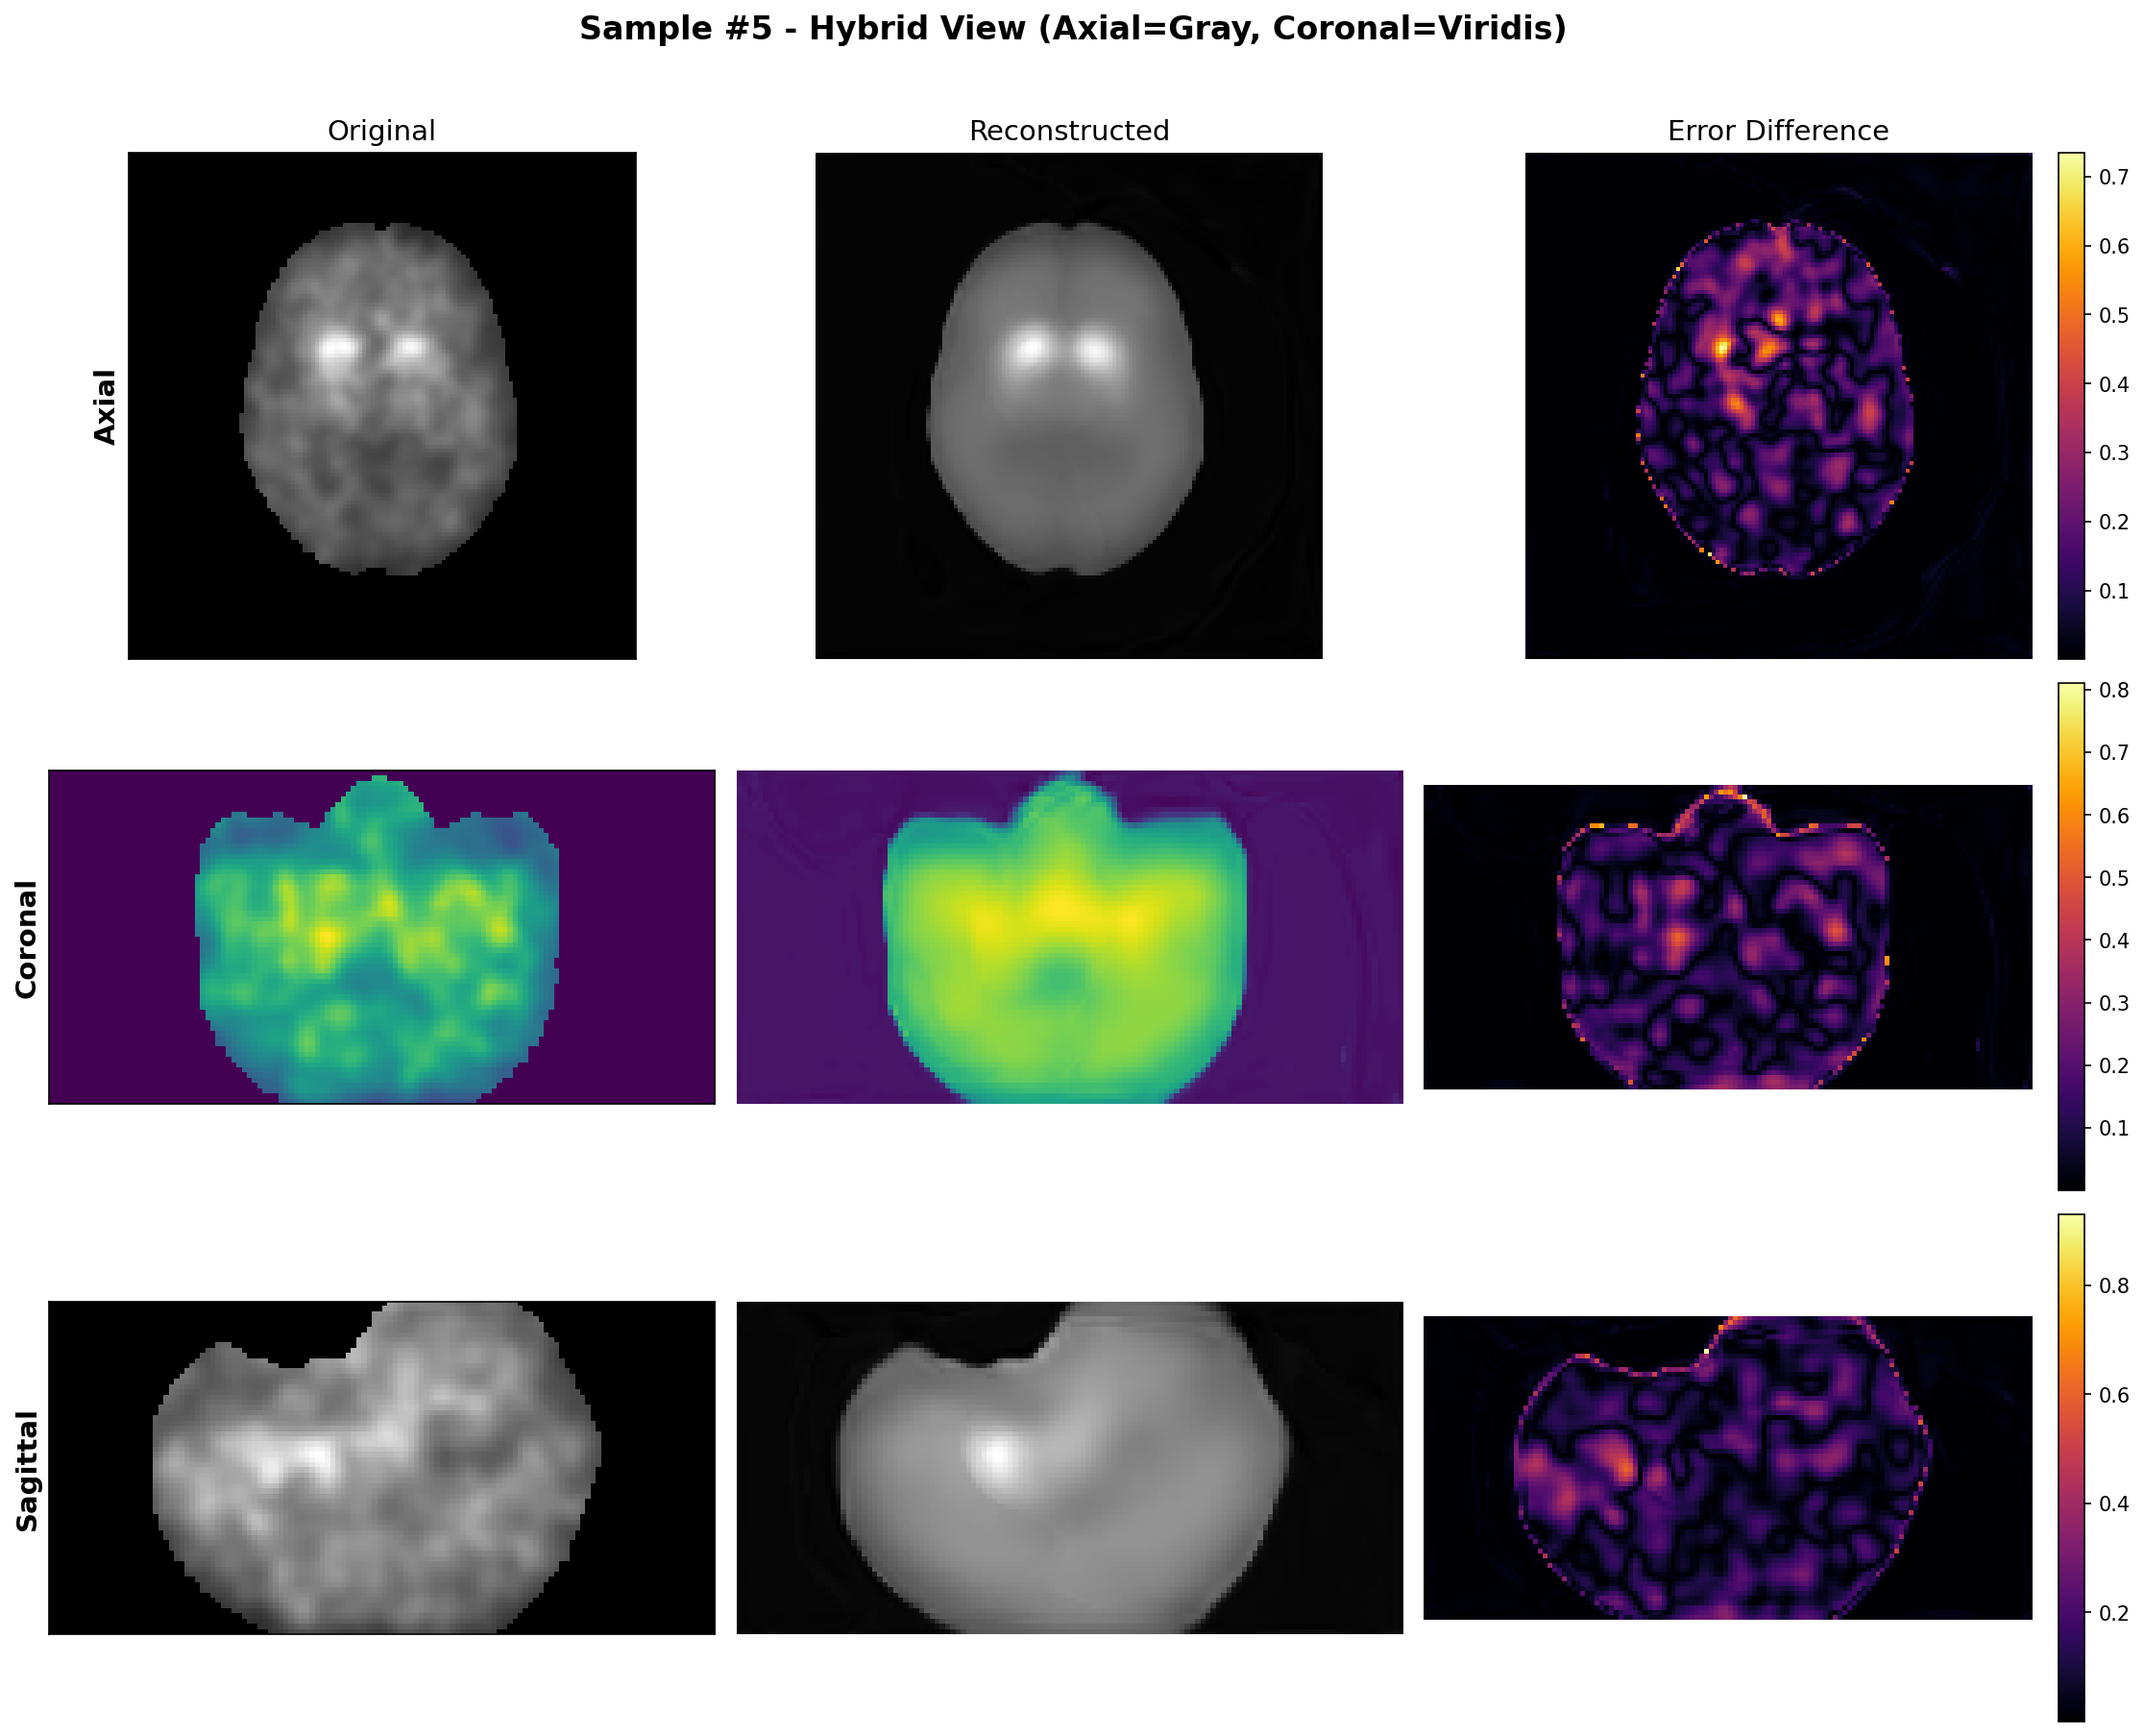

----------------------------------------------------------------------------------------------------


In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- 1. Collect 5 Samples ---
num_samples_needed = 5
collected_images = []
iter_loader = iter(val_loader)

while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break 

# Convert to tensor
sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- 2. Calculate Center Slices ---
_, _, D, H, W = sample_data.shape
mid_d, mid_h, mid_w = D // 2, H // 2, W // 2

# Define View Settings: (Name, Dimension, Slice Index, Colormap)
view_settings = [
    ('Axial',    0, mid_d, 'gray'),    # Axial stays GRAY
    ('Coronal',  1, mid_h, 'viridis'), # Coronal gets COLOR (Viridis)
    ('Sagittal', 2, mid_w, 'gray')     # Sagittal stays GRAY
]

# --- 3. Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- 4. Visualization Loop ---
for i in range(num_samples_needed):
    
    # Extract data (CPU)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create Figure
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} - Hybrid View (Axial=Gray, Coronal=Viridis)", fontsize=16, weight='bold', y=1)
    
    for row_idx, (view_name, dim_idx, slice_idx, cmap_style) in enumerate(view_settings):
        
        # Helper: Extract Slices
        if dim_idx == 0: # Axial
            s_orig = orig_np[slice_idx, :, :]
            s_recon = recon_np[slice_idx, :, :]
        elif dim_idx == 1: # Coronal
            s_orig = orig_np[:, slice_idx, :]
            s_recon = recon_np[:, slice_idx, :]
        elif dim_idx == 2: # Sagittal
            s_orig = orig_np[:, :, slice_idx]
            s_recon = recon_np[:, :, slice_idx]

        # Calculate Error
        s_error = np.abs(s_orig - s_recon)
        
        # --- PLOT COLUMN 1: ORIGINAL ---
        # Note: No 'aspect=auto', so shape remains correct/normal
        axes[row_idx, 0].imshow(s_orig, cmap=cmap_style)
        axes[row_idx, 0].set_ylabel(f"{view_name}", fontsize=14, weight='bold')
        
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        
        # Hide ticks
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # --- PLOT COLUMN 2: RECONSTRUCTED ---
        axes[row_idx, 1].imshow(s_recon, cmap=cmap_style)
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # --- PLOT COLUMN 3: ERROR ---
        # Error is always heatmap (Inferno) for visibility
        im = axes[row_idx, 2].imshow(s_error, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Colorbar
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    print("-" * 100)